In [1]:
%matplotlib inline

import intake

import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
import cartopy.crs as ccrs
import xarray as xr
import cmocean.cm as cmocean
import glob
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.path as mpath
import matplotlib.colors as col
import matplotlib.pyplot as pyplot

from netCDF4 import Dataset

import xesmf as xe

import warnings

from os import environ
environ["PYTHONWARNINGS"] = "ignore"

import logging
logging.captureWarnings(True)
logging.getLogger('py.warnings').setLevel(logging.ERROR)

from dask.distributed import Client

# figdir = '/g/data/e14/pc5520/figures/basal_melt_param/'
figdir = '/g/data/e14/fbd581/basal_mom5-collaborative-project/figures/'

In [2]:
client = Client(threads_per_worker=1)
client.dashboard_link

'/proxy/36075/status'

### old section using cosima cookbook

In [3]:
session_name = '/g/data/v45/wf4500/databases/gdata_01deg_jra55v13_ryf9091_DSW.db'
# 01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb
control = '01deg_jra55v13_ryf9091_DSW'
master_session = cc.database.create_session(session_name)

# session_name = '/g/data/e14/pc5520/model_data/access-om2/basal_melt_MOM5/basal_melt_MOM5.db'
session_name = '/g/data/ik11/databases/basal_melt_MOM5.db'
basal_melt_session = cc.database.create_session(session_name)
      
# temperature of meltwater using Gade line:
basal_gade = '01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb'
basal_gade_icb = '01deg_jra55v13_ryf9091_DSW_BasalGade_YesIcb'
basal_nogade = '01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb'
basal_gade_brine = '01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine'


NameError: name 'cc' is not defined

In [ ]:
%%time
# Make sure these match the available restarts:
start_time='1900-01-01'
end_time='1910-12-31'

lat_slice  = slice(-80,-59)

# load surface heat flux from different components:
sfc_hflux_from_runoff = cc.querying.getvar(control, 'sfc_hflux_from_runoff', master_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
sfc_hflux_coupler = cc.querying.getvar(control, 'sfc_hflux_coupler', master_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
sfc_hflux_pme = cc.querying.getvar(control, 'sfc_hflux_pme', master_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
frazil_3d_int_z = cc.querying.getvar(control, 'frazil_3d_int_z', master_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
swflx = cc.querying.getvar(control, 'swflx', master_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
lw_heat = cc.querying.getvar(control, 'lw_heat', master_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
sens_heat = cc.querying.getvar(control, 'sens_heat', master_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
evap_heat = cc.querying.getvar(control, 'evap_heat', master_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
fprec_melt_heat = cc.querying.getvar(control, 'fprec_melt_heat', master_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)

mhflux_ctrl = sfc_hflux_coupler - (swflx+lw_heat+sens_heat+evap_heat+fprec_melt_heat)

In [ ]:
%%time

sfc_hflux_from_runoff_noBG = cc.querying.getvar(basal_nogade, 'sfc_hflux_from_runoff', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
sfc_hflux_coupler_noBG = cc.querying.getvar(basal_nogade, 'sfc_hflux_coupler', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
sfc_hflux_pme_noBG = cc.querying.getvar(basal_nogade, 'sfc_hflux_pme', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
frazil_3d_int_z_noBG = cc.querying.getvar(basal_nogade, 'frazil_3d_int_z', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
temp_basalmix_noBG = cc.querying.getvar(basal_nogade, 'temp_basalmix', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
temp_icbmix_noBG = cc.querying.getvar(basal_nogade, 'temp_icbmix', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
swflx_noBG = cc.querying.getvar(basal_nogade, 'swflx', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
lw_heat_noBG = cc.querying.getvar(basal_nogade, 'lw_heat', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
sens_heat_noBG = cc.querying.getvar(basal_nogade, 'sens_heat', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
evap_heat_noBG = cc.querying.getvar(basal_nogade, 'evap_heat', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
fprec_melt_heat_noBG = cc.querying.getvar(basal_nogade, 'fprec_melt_heat', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)

mhflux_noBG = sfc_hflux_coupler_noBG - (swflx_noBG+lw_heat_noBG+sens_heat_noBG+evap_heat_noBG+fprec_melt_heat_noBG)

In [ ]:
%%time

sfc_hflux_from_runoff_BG = cc.querying.getvar(basal_gade, 'sfc_hflux_from_runoff', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
sfc_hflux_coupler_BG = cc.querying.getvar(basal_gade, 'sfc_hflux_coupler', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
sfc_hflux_pme_BG = cc.querying.getvar(basal_gade, 'sfc_hflux_pme', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
frazil_3d_int_z_BG = cc.querying.getvar(basal_gade, 'frazil_3d_int_z', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
temp_basalmix_BG = cc.querying.getvar(basal_gade, 'temp_basalmix', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
temp_icbmix_BG = cc.querying.getvar(basal_gade, 'temp_icbmix', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
swflx_BG = cc.querying.getvar(basal_gade, 'swflx', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
lw_heat_BG = cc.querying.getvar(basal_gade, 'lw_heat', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
sens_heat_BG = cc.querying.getvar(basal_gade, 'sens_heat', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
evap_heat_BG = cc.querying.getvar(basal_gade, 'evap_heat', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
fprec_melt_heat_BG = cc.querying.getvar(basal_gade, 'fprec_melt_heat', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)

mhflux_BG = sfc_hflux_coupler_BG - (swflx_BG+lw_heat_BG+sens_heat_BG+evap_heat_BG+fprec_melt_heat_BG)

In [ ]:
%%time
sfc_hflux_from_runoff_ICB = cc.querying.getvar(basal_gade_icb, 'sfc_hflux_from_runoff', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
sfc_hflux_coupler_ICB = cc.querying.getvar(basal_gade_icb, 'sfc_hflux_coupler', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
sfc_hflux_pme_ICB = cc.querying.getvar(basal_gade_icb, 'sfc_hflux_pme', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
frazil_3d_int_z_ICB = cc.querying.getvar(basal_gade_icb, 'frazil_3d_int_z', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
temp_basalmix_ICB = cc.querying.getvar(basal_gade_icb, 'temp_basalmix', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
temp_icbmix_ICB = cc.querying.getvar(basal_gade_icb, 'temp_icbmix', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
swflx_ICB = cc.querying.getvar(basal_gade_icb, 'swflx', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
lw_heat_ICB = cc.querying.getvar(basal_gade_icb, 'lw_heat', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
sens_heat_ICB = cc.querying.getvar(basal_gade_icb, 'sens_heat', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
evap_heat_ICB = cc.querying.getvar(basal_gade_icb, 'evap_heat', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
fprec_melt_heat_ICB = cc.querying.getvar(basal_gade_icb, 'fprec_melt_heat', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)

mhflux_ICB = sfc_hflux_coupler_ICB - (swflx_ICB+lw_heat_ICB+sens_heat_ICB+evap_heat_ICB+fprec_melt_heat_ICB)

In [ ]:
%%time

sfc_hflux_from_runoff_BGB = cc.querying.getvar(basal_gade_brine, 'sfc_hflux_from_runoff', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
sfc_hflux_coupler_BGB = cc.querying.getvar(basal_gade_brine, 'sfc_hflux_coupler', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
sfc_hflux_pme_BGB = cc.querying.getvar(basal_gade_brine, 'sfc_hflux_pme', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
frazil_3d_int_z_BGB = cc.querying.getvar(basal_gade_brine, 'frazil_3d_int_z', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
temp_basalmix_BGB = cc.querying.getvar(basal_gade_brine, 'temp_basalmix', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
swflx_BGB = cc.querying.getvar(basal_gade_brine, 'swflx', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
lw_heat_BGB = cc.querying.getvar(basal_gade_brine, 'lw_heat', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
sens_heat_BGB = cc.querying.getvar(basal_gade_brine, 'sens_heat', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
evap_heat_BGB = cc.querying.getvar(basal_gade_brine, 'evap_heat', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)
fprec_melt_heat_BGB = cc.querying.getvar(basal_gade_brine, 'fprec_melt_heat', basal_melt_session, start_time=start_time, end_time=end_time, frequency='1 monthly')[82:118,:,:].sel(yt_ocean=lat_slice)

mhflux_BGB = sfc_hflux_coupler_BGB - (swflx_BGB+lw_heat_BGB+sens_heat_BGB+evap_heat_BGB+fprec_melt_heat_BGB)

In [ ]:
# topography data for plotting:
ht = cc.querying.getvar(control,'ht' , master_session,n=1).sel(yt_ocean=lat_slice)
land_mask = np.squeeze(ht.values)*0
land_mask[np.isnan(land_mask)] = 1
land_mask = np.where(land_mask==1,land_mask,np.nan)
land_mask_masked = np.ma.masked_where((land_mask==0),land_mask)
# make land go all the way to -90S:
land_mask_lat = ht.yt_ocean.values
land_mask_lat[0] = -90

fontsize=15

### new section using catalog intake

In [3]:
# add experiments to my own intake:

# - control:
path_ctrl = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath"

# - basal No Gade: GPC029 (Basal)   
path_noBG = '/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb'

# - basal Gade: GPC023 (Basal_LH)   
# path_BG = '/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb'

# - basal Gade Brine: GPC062 (Basal_LH_Brine)    
path_BGB = '/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine_rep'


In [4]:
# add SOFIA experiments:
# path_ctrl_sofia = "/g/data/v45/wf4500/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath_sofia_ssp126"
path_ctrl_sofia = "/scratch/e14/fbd581/access-om2/fbd581/access-om2/archive/01deg_jra55_ryf9091_21mbath_sofia_ssp126-2612799a"

path_noBG_sofia = "/g/data/v45/wf4500/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb_sofia_ssp126"

path_BGB_sofia = "/g/data/v45/wf4500/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine_sofia_ssp126"


In [5]:
from access_nri_intake.source.builders import AccessOm2Builder


In [6]:
# %%time

# builder = AccessOm2Builder(
#     path=path_ctrl
# ).build()

# builder.save(
#     name="DSW_control", 
#     description="An example datastore for ACCESS-OM2 ryf9091 DSW control",
# )

In [7]:
# %%time

# builder = AccessOm2Builder(
#     path=path_noBG
# ).build()

# builder.save(
#     name="Basal", 
#     description="Datastore for ACCESS-OM2 ryf9091 Basal",
# )

In [8]:
# %%time

# builder = AccessOm2Builder(
#     path=path_BG
# ).build()

# builder.save(
#     name="Basal_LH", 
#     description="Datastore for ACCESS-OM2 ryf9091 Basal_LH",
# )

In [9]:
# %%time

# builder = AccessOm2Builder(
#     path=path_BGB,
#     exclude_patterns ='2delete_output041'
# ).build()

# builder.save(
#     name="Basal_LH_Brine", 
#     description="Datastore for ACCESS-OM2 ryf9091 Basal_LH_Brine",
# )

In [10]:
# %%time

# builder = AccessOm2Builder(
#     path=path_ctrl_sofia
# ).build()

# builder.save(
#     name="Control_SOFIA", 
#     description="An example datastore for ACCESS-OM2 ryf9091 SOFIA SSP1.2-6",
# )

In [11]:
cat = intake.open_esm_datastore(
    "./DSW_control.json",
    columns_with_iterables=["variable"] # This is important
)
# ds = cat.search(variable="temp").to_dask()

cat_noBG = intake.open_esm_datastore(
    "./Basal.json",
    columns_with_iterables=["variable"] # This is important
)

# cat_BG = intake.open_esm_datastore(
#     "./Basal_LH.json",
#     columns_with_iterables=["variable"] # This is important
# )

cat_BGB = intake.open_esm_datastore(
    "./Basal_LH_Brine.json",
    columns_with_iterables=["variable"] # This is important
)

In [12]:
cat_sofia = intake.open_esm_datastore(
    "./DSW_control_sofia.json",
    columns_with_iterables=["variable"] # This is important
)

cat_noBG_sofia = intake.open_esm_datastore(
    "./Basal_sofia.json",
    columns_with_iterables=["variable"] # This is important
)

cat_BGB_sofia = intake.open_esm_datastore(
    "./Basal_LH_Brine_sofia.json",
    columns_with_iterables=["variable"] # This is important
)

In [13]:
%%time
# Make sure these match the available restarts:
start_time='1917-01-01'
end_time='1919-12-31'
lat_slice  = slice(-80,-59)


CPU times: user 9 μs, sys: 0 ns, total: 9 μs
Wall time: 16.2 μs


In [14]:
%%time

# load surface heat flux from different components:
d1 = cat.search(variable='sfc_hflux_from_runoff', frequency='1mon').to_dask()
sfc_hflux_from_runoff_ctrl = d1.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d2 = cat.search(variable='sfc_hflux_coupler', frequency='1mon').to_dask()
sfc_hflux_coupler_ctrl = d2.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d3 = cat.search(variable='sfc_hflux_pme', frequency='1mon').to_dask()
sfc_hflux_pme_ctrl = d3.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d4 = cat.search(variable='frazil_3d_int_z', frequency='1mon').to_dask()
frazil_3d_int_z_ctrl = d4.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d5 = cat.search(variable='swflx', frequency='1mon').to_dask()
swflx_ctrl = d5.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d6 = cat.search(variable='lw_heat', frequency='1mon').to_dask()
lw_heat_ctrl = d6.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d7 = cat.search(variable='sens_heat', frequency='1mon').to_dask()
sens_heat_ctrl = d7.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d8 = cat.search(variable='evap_heat', frequency='1mon').to_dask()
evap_heat_ctrl = d8.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d9 = cat.search(variable='fprec_melt_heat', frequency='1mon').to_dask()
fprec_melt_heat_ctrl = d9.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

mhflux_ctrl = sfc_hflux_coupler_ctrl.to_dataarray().squeeze() - \
            (swflx_ctrl.to_dataarray().squeeze() +lw_heat_ctrl.to_dataarray().squeeze() + \
             sens_heat_ctrl.to_dataarray().squeeze() +evap_heat_ctrl.to_dataarray().squeeze() + \
             fprec_melt_heat_ctrl.to_dataarray().squeeze())


CPU times: user 7.14 s, sys: 758 ms, total: 7.9 s
Wall time: 18.7 s


In [15]:
swflx_ctrl

<xarray.Dataset> Size: 250MB
Dimensions:   (time: 36, yt_ocean: 483, xt_ocean: 3600)
Coordinates:
  * xt_ocean  (xt_ocean) float64 29kB -279.9 -279.8 -279.7 ... 79.75 79.85 79.95
  * yt_ocean  (yt_ocean) float64 4kB -79.97 -79.93 -79.88 ... -59.08 -59.03
  * time      (time) object 288B 1917-01-16 12:00:00 ... 1919-12-16 12:00:00
Data variables:
    swflx     (time, yt_ocean, xt_ocean) float32 250MB dask.array<chunksize=(1, 483, 720), meta=np.ndarray>
Attributes: (12/16)
    filename:                                 ocean_month.nc
    title:                                    ACCESS-OM2-01
    grid_type:                                mosaic
    grid_tile:                                1
    intake_esm_vars:                          ['swflx']
    intake_esm_attrs:filename:                ocean_month.nc
    ...                                       ...
    intake_esm_attrs:variable_standard_name:  ['', '', '', '', '', '', 'sea_s...
    intake_esm_attrs:variable_cell_methods:   ['', '', '', '', '', '', 'time:...
    intake_esm_attrs:variable_units:          ['degrees_E', 'degrees_N', 'day...
    intake_esm_attrs:realm:                   ocean
    intake_esm_attrs:_data_format_:           netcdf
    intake_esm_dataset_key:                   ocean_month.1mon

In [16]:
%%time

# load surface heat flux from different components:
d1 = cat_noBG.search(variable='sfc_hflux_from_runoff', frequency='1mon').to_dask()
sfc_hflux_from_runoff_noBG = d1.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d2 = cat_noBG.search(variable='sfc_hflux_coupler', frequency='1mon').to_dask()
sfc_hflux_coupler_noBG = d2.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d3 = cat_noBG.search(variable='sfc_hflux_pme', frequency='1mon').to_dask()
sfc_hflux_pme_noBG = d3.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d4 = cat_noBG.search(variable='frazil_3d_int_z', frequency='1mon').to_dask()
frazil_3d_int_z_noBG = d4.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d5 = cat_noBG.search(variable='swflx', frequency='1mon').to_dask()
swflx_noBG = d5.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d6 = cat_noBG.search(variable='lw_heat', frequency='1mon').to_dask()
lw_heat_noBG = d6.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d7 = cat_noBG.search(variable='sens_heat', frequency='1mon').to_dask()
sens_heat_noBG = d7.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d8 = cat_noBG.search(variable='evap_heat', frequency='1mon').to_dask()
evap_heat_noBG = d8.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d9 = cat_noBG.search(variable='fprec_melt_heat', frequency='1mon').to_dask()
fprec_melt_heat_noBG = d9.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

mhflux_noBG = sfc_hflux_coupler_noBG.to_dataarray().squeeze() - \
            (swflx_noBG.to_dataarray().squeeze() +lw_heat_noBG.to_dataarray().squeeze() + \
             sens_heat_noBG.to_dataarray().squeeze() +evap_heat_noBG.to_dataarray().squeeze() + \
             fprec_melt_heat_noBG.to_dataarray().squeeze())

d10 = cat_noBG.search(variable='temp_basalmix', frequency='1mon').to_dask()
temp_basalmix_noBG = d10.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d11 = cat_noBG.search(variable='temp_icbmix', frequency='1mon').to_dask()
temp_icbmix_noBG = d11.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)


CPU times: user 14.6 s, sys: 1.11 s, total: 15.7 s
Wall time: 18.2 s


In [17]:
# %%time

# # load surface heat flux from different components:
# d1 = cat_BG.search(variable='sfc_hflux_from_runoff', frequency='1mon').to_dask()
# sfc_hflux_from_runoff_BG = d1.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

# d2 = cat_BG.search(variable='sfc_hflux_coupler', frequency='1mon').to_dask()
# sfc_hflux_coupler_BG = d2.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

# d3 = cat_BG.search(variable='sfc_hflux_pme', frequency='1mon').to_dask()
# sfc_hflux_pme_BG = d3.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

# d4 = cat_BG.search(variable='frazil_3d_int_z', frequency='1mon').to_dask()
# frazil_3d_int_z_BG = d4.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

# d5 = cat_BG.search(variable='swflx', frequency='1mon').to_dask()
# swflx_BG = d5.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

# d6 = cat_BG.search(variable='lw_heat', frequency='1mon').to_dask()
# lw_heat_BG = d6.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

# d7 = cat_BG.search(variable='sens_heat', frequency='1mon').to_dask()
# sens_heat_BG = d7.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

# d8 = cat_BG.search(variable='evap_heat', frequency='1mon').to_dask()
# evap_heat_BG = d8.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

# d9 = cat_BG.search(variable='fprec_melt_heat', frequency='1mon').to_dask()
# fprec_melt_heat_BG = d9.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

# mhflux_BG = sfc_hflux_coupler_BG.to_dataarray().squeeze() - \
#             (swflx_BG.to_dataarray().squeeze() +lw_heat_BG .to_dataarray().squeeze() + \
#              sens_heat_BG.to_dataarray().squeeze() +evap_heat_BG.to_dataarray().squeeze() + \
#              fprec_melt_heat_BG.to_dataarray().squeeze())

# d10 = cat_BG.search(variable='temp_basalmix', frequency='1mon').to_dask()
# temp_basalmix_BG = d10.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

# d11 = cat_BG.search(variable='temp_icbmix', frequency='1mon').to_dask()
# temp_icbmix_BG = d11.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)



In [18]:
%%time

# load surface heat flux from different components:
d1 = cat_BGB.search(variable='sfc_hflux_from_runoff', frequency='1mon').to_dask()
sfc_hflux_from_runoff_BGB = d1.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d2 = cat_BGB.search(variable='sfc_hflux_coupler', frequency='1mon').to_dask()
sfc_hflux_coupler_BGB = d2.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d3 = cat_BGB.search(variable='sfc_hflux_pme', frequency='1mon').to_dask()
sfc_hflux_pme_BGB = d3.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d4 = cat_BGB.search(variable='frazil_3d_int_z', frequency='1mon').to_dask()
frazil_3d_int_z_BGB = d4.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d5 = cat_BGB.search(variable='swflx', frequency='1mon').to_dask()
swflx_BGB = d5.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d6 = cat_BGB.search(variable='lw_heat', frequency='1mon').to_dask()
lw_heat_BGB = d6.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d7 = cat_BGB.search(variable='sens_heat', frequency='1mon').to_dask()
sens_heat_BGB = d7.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d8 = cat_BGB.search(variable='evap_heat', frequency='1mon').to_dask()
evap_heat_BGB = d8.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d9 = cat_BGB.search(variable='fprec_melt_heat', frequency='1mon').to_dask()
fprec_melt_heat_BGB = d9.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

mhflux_BGB = sfc_hflux_coupler_BGB.to_dataarray().squeeze() - \
            (swflx_BGB.to_dataarray().squeeze() +lw_heat_BGB.to_dataarray().squeeze() + \
             sens_heat_BGB.to_dataarray().squeeze() +evap_heat_BGB.to_dataarray().squeeze() + \
             fprec_melt_heat_BGB.to_dataarray().squeeze())

d10 = cat_BGB.search(variable='temp_basalmix', frequency='1mon').to_dask()
temp_basalmix_BGB = d10.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

# d11 = cat_BGB.search(variable='temp_icbmix', frequency='1mon').to_dask()
# temp_icbmix_BGB = d11.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)



CPU times: user 8.79 s, sys: 753 ms, total: 9.54 s
Wall time: 12.6 s


In [19]:
%%time
# SOFIA control

# load surface heat flux from different components:
d1s = cat_sofia.search(variable='sfc_hflux_from_runoff', frequency='1mon').to_dask()
sfc_hflux_from_runoff_ctrl_sofia= d1s.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d2s = cat_sofia.search(variable='sfc_hflux_coupler', frequency='1mon').to_dask()
sfc_hflux_coupler_ctrl_sofia= d2s.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d3s = cat_sofia.search(variable='sfc_hflux_pme', frequency='1mon').to_dask()
sfc_hflux_pme_ctrl_sofia= d3s.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d4s = cat_sofia.search(variable='frazil_3d_int_z', frequency='1mon').to_dask()
frazil_3d_int_z_ctrl_sofia= d4s.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d5s = cat_sofia.search(variable='swflx', frequency='1mon').to_dask()
swflx_ctrl_sofia= d5s.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d6s = cat_sofia.search(variable='lw_heat', frequency='1mon').to_dask()
lw_heat_ctrl_sofia= d6s.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d7s = cat_sofia.search(variable='sens_heat', frequency='1mon').to_dask()
sens_heat_ctrl_sofia= d7s.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d8s = cat_sofia.search(variable='evap_heat', frequency='1mon').to_dask()
evap_heat_ctrl_sofia= d8s.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d9s = cat_sofia.search(variable='fprec_melt_heat', frequency='1mon').to_dask()
fprec_melt_heat_ctrl_sofia= d9s.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

mhflux_ctrl_sofia= sfc_hflux_coupler_ctrl_sofia.to_dataarray().squeeze() - \
            (swflx_ctrl_sofia.to_dataarray().squeeze() +lw_heat_ctrl_sofia.to_dataarray().squeeze() + \
             sens_heat_ctrl_sofia.to_dataarray().squeeze() +evap_heat_ctrl_sofia.to_dataarray().squeeze() + \
             fprec_melt_heat_ctrl_sofia.to_dataarray().squeeze())


CPU times: user 4.33 s, sys: 291 ms, total: 4.62 s
Wall time: 5.75 s


In [20]:
%%time
## SOFIA Basal (noGade)

# load surface heat flux from different components:
d1 = cat_noBG_sofia.search(variable='sfc_hflux_from_runoff', frequency='1mon').to_dask()
sfc_hflux_from_runoff_noBG_sofia = d1.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d2 = cat_noBG_sofia.search(variable='sfc_hflux_coupler', frequency='1mon').to_dask()
sfc_hflux_coupler_noBG_sofia = d2.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d3 = cat_noBG_sofia.search(variable='sfc_hflux_pme', frequency='1mon').to_dask()
sfc_hflux_pme_noBG_sofia = d3.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d4 = cat_noBG_sofia.search(variable='frazil_3d_int_z', frequency='1mon').to_dask()
frazil_3d_int_z_noBG_sofia = d4.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d5 = cat_noBG_sofia.search(variable='swflx', frequency='1mon').to_dask()
swflx_noBG_sofia = d5.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d6 = cat_noBG_sofia.search(variable='lw_heat', frequency='1mon').to_dask()
lw_heat_noBG_sofia = d6.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d7 = cat_noBG_sofia.search(variable='sens_heat', frequency='1mon').to_dask()
sens_heat_noBG_sofia = d7.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d8 = cat_noBG_sofia.search(variable='evap_heat', frequency='1mon').to_dask()
evap_heat_noBG_sofia = d8.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d9 = cat_noBG_sofia.search(variable='fprec_melt_heat', frequency='1mon').to_dask()
fprec_melt_heat_noBG_sofia = d9.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

mhflux_noBG_sofia = sfc_hflux_coupler_noBG_sofia.to_dataarray().squeeze() - \
            (swflx_noBG_sofia.to_dataarray().squeeze() +lw_heat_noBG_sofia.to_dataarray().squeeze() + \
             sens_heat_noBG_sofia.to_dataarray().squeeze() +evap_heat_noBG_sofia.to_dataarray().squeeze() + \
             fprec_melt_heat_noBG_sofia.to_dataarray().squeeze())

d10 = cat_noBG_sofia.search(variable='temp_basalmix', frequency='1mon').to_dask()
temp_basalmix_noBG_sofia = d10.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d11 = cat_noBG_sofia.search(variable='temp_icbmix', frequency='1mon').to_dask()
temp_icbmix_noBG_sofia = d11.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)


CPU times: user 4.29 s, sys: 350 ms, total: 4.64 s
Wall time: 5.6 s


In [21]:
%%time

# load surface heat flux from different components:
d1 = cat_BGB_sofia.search(variable='sfc_hflux_from_runoff', frequency='1mon').to_dask()
sfc_hflux_from_runoff_BGB_sofia = d1.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d2 = cat_BGB_sofia.search(variable='sfc_hflux_coupler', frequency='1mon').to_dask()
sfc_hflux_coupler_BGB_sofia = d2.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d3 = cat_BGB_sofia.search(variable='sfc_hflux_pme', frequency='1mon').to_dask()
sfc_hflux_pme_BGB_sofia = d3.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d4 = cat_BGB_sofia.search(variable='frazil_3d_int_z', frequency='1mon').to_dask()
frazil_3d_int_z_BGB_sofia = d4.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d5 = cat_BGB_sofia.search(variable='swflx', frequency='1mon').to_dask()
swflx_BGB_sofia = d5.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d6 = cat_BGB_sofia.search(variable='lw_heat', frequency='1mon').to_dask()
lw_heat_BGB_sofia = d6.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d7 = cat_BGB_sofia.search(variable='sens_heat', frequency='1mon').to_dask()
sens_heat_BGB_sofia = d7.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d8 = cat_BGB_sofia.search(variable='evap_heat', frequency='1mon').to_dask()
evap_heat_BGB_sofia = d8.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

d9 = cat_BGB_sofia.search(variable='fprec_melt_heat', frequency='1mon').to_dask()
fprec_melt_heat_BGB_sofia = d9.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

mhflux_BGB_sofia = sfc_hflux_coupler_BGB_sofia.to_dataarray().squeeze() - \
            (swflx_BGB_sofia.to_dataarray().squeeze() +lw_heat_BGB_sofia.to_dataarray().squeeze() + \
             sens_heat_BGB_sofia.to_dataarray().squeeze() +evap_heat_BGB_sofia.to_dataarray().squeeze() + \
             fprec_melt_heat_BGB_sofia.to_dataarray().squeeze())

d10 = cat_BGB_sofia.search(variable='temp_basalmix', frequency='1mon').to_dask()
temp_basalmix_BGB_sofia = d10.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)

# d11 = cat_BGB_sofia.search(variable='temp_icbmix', frequency='1mon').to_dask()
# temp_icbmix_BGB_sofia = d11.sel(time=slice(start_time, end_time),yt_ocean=lat_slice)



CPU times: user 6.43 s, sys: 476 ms, total: 6.91 s
Wall time: 8.06 s


In [26]:
# d1 = cat.search(variable="area_t",path='/g/data/v45/wf4500/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW/output000/ocean/ocean_grid.nc').to_dask()
d1 = cat.search(variable="area_t",path='/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath/output000/ocean/ocean_grid.nc').to_dask()
oc_grd = d1.sel(yt_ocean=lat_slice)
area_t = oc_grd.area_t

d2 = cat.search(variable="ht",path='/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath/output000/ocean/ocean_grid.nc').to_dask()
oc_grd = d2.sel(yt_ocean=lat_slice)
ht = oc_grd.ht

land_mask = np.squeeze(ht)*0
land_mask_fld = land_mask.fillna(1)
land_mask_fld = np.where(land_mask_fld==1,land_mask_fld,np.nan)
land_mask_masked = np.ma.masked_where((land_mask_fld==0),land_mask_fld)

# make land go all the way to -90S:
land_mask_lat = ht.yt_ocean.values
land_mask_lat[0] = -90

fontsize=15

In [27]:
%%time
import numpy.ma as ma

# function to do annual avg and horiz. integral: ONLY SHELF
def var_tavg_hint_shelf(var2d):
    var = var2d.mean('time') # annual mean
    var_masked = ma.masked_where(ht > 1000, var) # masked offshore 1000m isobath
    var_masked_area = var_masked*area_t # multiply by area
    var_hint = np.nansum(np.nansum(var_masked_area, axis=1), axis=0) # sum along x/y axis

    return var_hint

# function to do ONLY horiz. integral: ONLY SHELF
def var_hint_shelf(var2d):
    var_masked = ma.masked_where(ht > 1000, var2d) # masked offshore 1000m isobath
    var_masked_area = var_masked*area_t # multiply by area
    var_hint = np.nansum(np.nansum(var_masked_area, axis=1), axis=0) # sum along x/y axis

    return var_hint

# function to do annual avg and horiz. integral: GLOBAL
def var_tavg_hint(var2d):
    var = var2d.mean('time') # annual mean
    var_area = var*area_t # multiply by area
    var_hint = np.nansum(np.nansum(var_area, axis=1), axis=0) # sum along x/y axis

    return var_hint

CPU times: user 27 μs, sys: 0 ns, total: 27 μs
Wall time: 46 μs


In [28]:
%%time

# Control experiment:

# self-only
HF_runoff_annual_hint_shelf_ctrl = var_tavg_hint_shelf(sfc_hflux_from_runoff_ctrl.to_dataarray().squeeze())
HF_coupler_annual_hint_shelf_ctrl = var_tavg_hint_shelf(sfc_hflux_coupler_ctrl.to_dataarray().squeeze())
HF_pme_annual_hint_shelf_ctrl = var_tavg_hint_shelf(sfc_hflux_pme_ctrl.to_dataarray().squeeze())
HF_frazil_annual_hint_shelf_ctrl = var_tavg_hint_shelf(frazil_3d_int_z_ctrl.to_dataarray().squeeze())
HF_sw_annual_hint_shelf_ctrl = var_tavg_hint_shelf(swflx_ctrl.to_dataarray().squeeze())
HF_lw_annual_hint_shelf_ctrl = var_tavg_hint_shelf(lw_heat_ctrl.to_dataarray().squeeze())
HF_sens_annual_hint_shelf_ctrl = var_tavg_hint_shelf(sens_heat_ctrl.to_dataarray().squeeze())
HF_evap_annual_hint_shelf_ctrl = var_tavg_hint_shelf(evap_heat_ctrl.to_dataarray().squeeze())
HF_fprec_annual_hint_shelf_ctrl = var_tavg_hint_shelf(fprec_melt_heat_ctrl.to_dataarray().squeeze())
HF_mh_annual_hint_shelf_ctrl = var_tavg_hint_shelf(mhflux_ctrl)


CPU times: user 9.6 s, sys: 926 ms, total: 10.5 s
Wall time: 14.4 s


In [29]:
%%time

# Basal_NOgade experiment:

# shelf-only
HF_runoff_annual_hint_shelf_noBG = var_tavg_hint_shelf(sfc_hflux_from_runoff_noBG.to_dataarray().squeeze())
HF_coupler_annual_hint_shelf_noBG = var_tavg_hint_shelf(sfc_hflux_coupler_noBG.to_dataarray().squeeze())
HF_pme_annual_hint_shelf_noBG = var_tavg_hint_shelf(sfc_hflux_pme_noBG.to_dataarray().squeeze())
HF_frazil_annual_hint_shelf_noBG = var_tavg_hint_shelf(frazil_3d_int_z_noBG.to_dataarray().squeeze())
HF_sw_annual_hint_shelf_noBG = var_tavg_hint_shelf(swflx_noBG.to_dataarray().squeeze())
HF_lw_annual_hint_shelf_noBG = var_tavg_hint_shelf(lw_heat_noBG.to_dataarray().squeeze())
HF_sens_annual_hint_shelf_noBG = var_tavg_hint_shelf(sens_heat_noBG.to_dataarray().squeeze())
HF_evap_annual_hint_shelf_noBG = var_tavg_hint_shelf(evap_heat_noBG.to_dataarray().squeeze())
HF_fprec_annual_hint_shelf_noBG = var_tavg_hint_shelf(fprec_melt_heat_noBG.to_dataarray().squeeze())

# first get vertical sum of basal mix:
HF_basalmix_annual_vint_noBG = temp_basalmix_noBG.sum('st_ocean')

HF_basalmix_annual_hint_shelf_noBG = var_tavg_hint_shelf(HF_basalmix_annual_vint_noBG.to_dataarray().squeeze())
HF_mh_annual_hint_shelf_noBG = var_tavg_hint_shelf(mhflux_noBG)

CPU times: user 38.7 s, sys: 1.79 s, total: 40.5 s
Wall time: 45.2 s


In [30]:
# %%time

# # Basal_gade experiment:

# # shelf-only
# HF_runoff_annual_hint_shelf_BG = var_tavg_hint_shelf(sfc_hflux_from_runoff_BG.to_dataarray().squeeze())
# HF_coupler_annual_hint_shelf_BG = var_tavg_hint_shelf(sfc_hflux_coupler_BG.to_dataarray().squeeze())
# HF_pme_annual_hint_shelf_BG = var_tavg_hint_shelf(sfc_hflux_pme_BG.to_dataarray().squeeze())
# HF_frazil_annual_hint_shelf_BG = var_tavg_hint_shelf(frazil_3d_int_z_BG.to_dataarray().squeeze())
# HF_sw_annual_hint_shelf_BG = var_tavg_hint_shelf(swflx_BG.to_dataarray().squeeze())
# HF_lw_annual_hint_shelf_BG = var_tavg_hint_shelf(lw_heat_BG.to_dataarray().squeeze())
# HF_sens_annual_hint_shelf_BG = var_tavg_hint_shelf(sens_heat_BG.to_dataarray().squeeze())
# HF_evap_annual_hint_shelf_BG = var_tavg_hint_shelf(evap_heat_BG.to_dataarray().squeeze())
# HF_fprec_annual_hint_shelf_BG = var_tavg_hint_shelf(fprec_melt_heat_BG.to_dataarray().squeeze())

# # first get vertical sum of basal mix:
# HF_basalmix_annual_vint_BG = temp_basalmix_BG.sum('st_ocean')

# HF_basalmix_annual_hint_shelf_BG = var_tavg_hint_shelf(HF_basalmix_annual_vint_BG.to_dataarray().squeeze())
# HF_mh_annual_hint_shelf_BG = var_tavg_hint_shelf(mhflux_BG)

In [31]:
%%time

# Basal_gade_brine experiment:

# shelf-only
HF_runoff_annual_hint_shelf_BGB = var_tavg_hint_shelf(sfc_hflux_from_runoff_BGB.to_dataarray().squeeze())
HF_coupler_annual_hint_shelf_BGB = var_tavg_hint_shelf(sfc_hflux_coupler_BGB.to_dataarray().squeeze())
HF_pme_annual_hint_shelf_BGB = var_tavg_hint_shelf(sfc_hflux_pme_BGB.to_dataarray().squeeze())
HF_frazil_annual_hint_shelf_BGB = var_tavg_hint_shelf(frazil_3d_int_z_BGB.to_dataarray().squeeze())
HF_sw_annual_hint_shelf_BGB = var_tavg_hint_shelf(swflx_BGB.to_dataarray().squeeze())
HF_lw_annual_hint_shelf_BGB = var_tavg_hint_shelf(lw_heat_BGB.to_dataarray().squeeze())
HF_sens_annual_hint_shelf_BGB = var_tavg_hint_shelf(sens_heat_BGB.to_dataarray().squeeze())
HF_evap_annual_hint_shelf_BGB = var_tavg_hint_shelf(evap_heat_BGB.to_dataarray().squeeze())
HF_fprec_annual_hint_shelf_BGB = var_tavg_hint_shelf(fprec_melt_heat_BGB.to_dataarray().squeeze())

# first get vertical sum of basal mix:
HF_basalmix_annual_vint_BGB = temp_basalmix_BGB.sum('st_ocean')

HF_basalmix_annual_hint_shelf_BGB = var_tavg_hint_shelf(HF_basalmix_annual_vint_BGB.to_dataarray().squeeze())
HF_mh_annual_hint_shelf_BGB = var_tavg_hint_shelf(mhflux_BGB)

CPU times: user 48.7 s, sys: 1.93 s, total: 50.6 s
Wall time: 57.3 s


In [32]:
%%time

# Control SOFIA experiment:

# self-only
HF_runoff_annual_hint_shelf_ctrl_sofia = var_tavg_hint_shelf(sfc_hflux_from_runoff_ctrl_sofia.to_dataarray().squeeze())
HF_coupler_annual_hint_shelf_ctrl_sofia = var_tavg_hint_shelf(sfc_hflux_coupler_ctrl_sofia.to_dataarray().squeeze())
HF_pme_annual_hint_shelf_ctrl_sofia = var_tavg_hint_shelf(sfc_hflux_pme_ctrl_sofia.to_dataarray().squeeze())
HF_frazil_annual_hint_shelf_ctrl_sofia = var_tavg_hint_shelf(frazil_3d_int_z_ctrl_sofia.to_dataarray().squeeze())
HF_sw_annual_hint_shelf_ctrl_sofia = var_tavg_hint_shelf(swflx_ctrl_sofia.to_dataarray().squeeze())
HF_lw_annual_hint_shelf_ctrl_sofia = var_tavg_hint_shelf(lw_heat_ctrl_sofia.to_dataarray().squeeze())
HF_sens_annual_hint_shelf_ctrl_sofia = var_tavg_hint_shelf(sens_heat_ctrl_sofia.to_dataarray().squeeze())
HF_evap_annual_hint_shelf_ctrl_sofia = var_tavg_hint_shelf(evap_heat_ctrl_sofia.to_dataarray().squeeze())
HF_fprec_annual_hint_shelf_ctrl_sofia = var_tavg_hint_shelf(fprec_melt_heat_ctrl_sofia.to_dataarray().squeeze())
HF_mh_annual_hint_shelf_ctrl_sofia = var_tavg_hint_shelf(mhflux_ctrl_sofia)


CPU times: user 10.7 s, sys: 844 ms, total: 11.5 s
Wall time: 15 s


In [33]:
%%time

# Basal_NOgade SOFIA experiment:

# shelf-only
HF_runoff_annual_hint_shelf_noBG_sofia = var_tavg_hint_shelf(sfc_hflux_from_runoff_noBG_sofia.to_dataarray().squeeze())
HF_coupler_annual_hint_shelf_noBG_sofia = var_tavg_hint_shelf(sfc_hflux_coupler_noBG_sofia.to_dataarray().squeeze())
HF_pme_annual_hint_shelf_noBG_sofia = var_tavg_hint_shelf(sfc_hflux_pme_noBG_sofia.to_dataarray().squeeze())
HF_frazil_annual_hint_shelf_noBG_sofia = var_tavg_hint_shelf(frazil_3d_int_z_noBG_sofia.to_dataarray().squeeze())
HF_sw_annual_hint_shelf_noBG_sofia = var_tavg_hint_shelf(swflx_noBG_sofia.to_dataarray().squeeze())
HF_lw_annual_hint_shelf_noBG_sofia = var_tavg_hint_shelf(lw_heat_noBG_sofia.to_dataarray().squeeze())
HF_sens_annual_hint_shelf_noBG_sofia = var_tavg_hint_shelf(sens_heat_noBG_sofia.to_dataarray().squeeze())
HF_evap_annual_hint_shelf_noBG_sofia = var_tavg_hint_shelf(evap_heat_noBG_sofia.to_dataarray().squeeze())
HF_fprec_annual_hint_shelf_noBG_sofia = var_tavg_hint_shelf(fprec_melt_heat_noBG_sofia.to_dataarray().squeeze())

# first get vertical sum of basal mix:
HF_basalmix_annual_vint_noBG_sofia = temp_basalmix_noBG_sofia.sum('st_ocean')

HF_basalmix_annual_hint_shelf_noBG_sofia = var_tavg_hint_shelf(HF_basalmix_annual_vint_noBG_sofia.to_dataarray().squeeze())
HF_mh_annual_hint_shelf_noBG_sofia = var_tavg_hint_shelf(mhflux_noBG)

CPU times: user 40.5 s, sys: 1.53 s, total: 42 s
Wall time: 46.4 s


In [34]:
%%time

# Basal_gade_brine SOFIA experiment:

# shelf-only
HF_runoff_annual_hint_shelf_BGB_sofia = var_tavg_hint_shelf(sfc_hflux_from_runoff_BGB_sofia.to_dataarray().squeeze())
HF_coupler_annual_hint_shelf_BGB_sofia = var_tavg_hint_shelf(sfc_hflux_coupler_BGB_sofia.to_dataarray().squeeze())
HF_pme_annual_hint_shelf_BGB_sofia = var_tavg_hint_shelf(sfc_hflux_pme_BGB_sofia.to_dataarray().squeeze())
HF_frazil_annual_hint_shelf_BGB_sofia = var_tavg_hint_shelf(frazil_3d_int_z_BGB_sofia.to_dataarray().squeeze())
HF_sw_annual_hint_shelf_BGB_sofia = var_tavg_hint_shelf(swflx_BGB_sofia.to_dataarray().squeeze())
HF_lw_annual_hint_shelf_BGB_sofia = var_tavg_hint_shelf(lw_heat_BGB_sofia.to_dataarray().squeeze())
HF_sens_annual_hint_shelf_BGB_sofia = var_tavg_hint_shelf(sens_heat_BGB_sofia.to_dataarray().squeeze())
HF_evap_annual_hint_shelf_BGB_sofia = var_tavg_hint_shelf(evap_heat_BGB_sofia.to_dataarray().squeeze())
HF_fprec_annual_hint_shelf_BGB_sofia = var_tavg_hint_shelf(fprec_melt_heat_BGB_sofia.to_dataarray().squeeze())

# first get vertical sum of basal mix:
HF_basalmix_annual_vint_BGB_sofia = temp_basalmix_BGB_sofia.sum('st_ocean')
HF_basalmix_annual_hint_shelf_BGB_sofia = var_tavg_hint_shelf(HF_basalmix_annual_vint_BGB_sofia.to_dataarray().squeeze())
HF_mh_annual_hint_shelf_BGB_sofia = var_tavg_hint_shelf(mhflux_BGB_sofia)

CPU times: user 51.2 s, sys: 1.79 s, total: 53 s
Wall time: 57.8 s


/g/data/e14/fbd581/basal_mom5-collaborative-project/figures/SHF_components_annual_hint_shelf_yr17-20.png


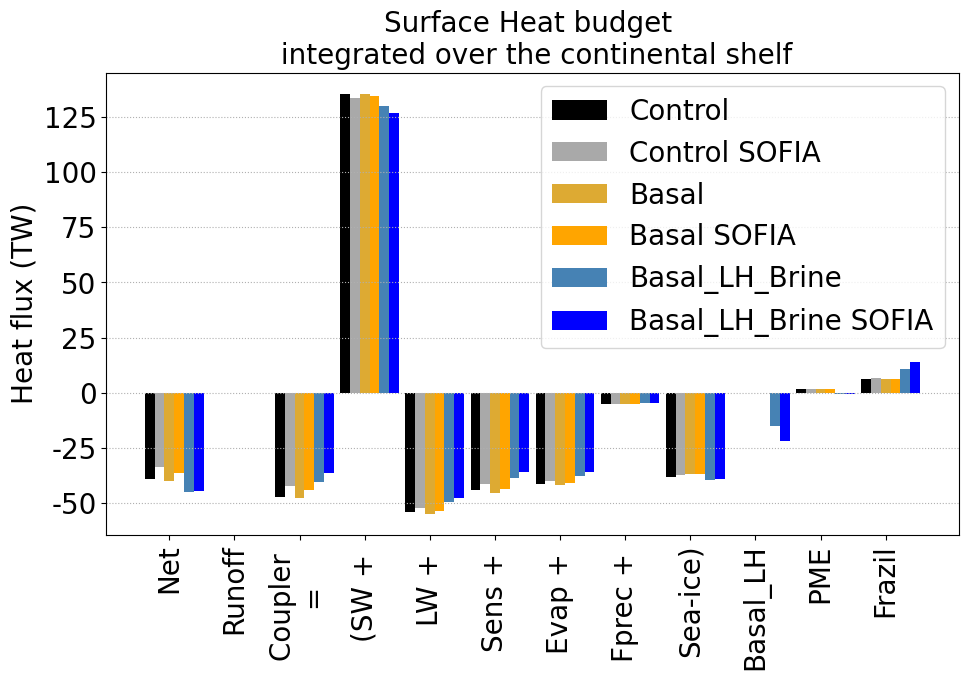

In [35]:
## plot with SOFIA expts

# plot with bars: last year annual avg, horizontally-integrated (over the shelf , depth<1000m only):
fig, ax  = plt.subplots(figsize = (11,6))

pyplot.bar(0.7, HF_runoff_annual_hint_shelf_ctrl*1e-12, width=0.15, color='k', label='Control')
pyplot.bar(0.85, HF_runoff_annual_hint_shelf_ctrl_sofia*1e-12, width=0.15, color='darkgray', label='Control SOFIA')
pyplot.bar(1, HF_runoff_annual_hint_shelf_noBG*1e-12, width=0.15, color='#DDAA33', label='Basal')
pyplot.bar(1.15, HF_runoff_annual_hint_shelf_noBG_sofia*1e-12, width=0.15, color='orange', label='Basal SOFIA')
pyplot.bar(1.3, HF_runoff_annual_hint_shelf_BGB*1e-12, width=0.15, color='steelblue', label='Basal_LH_Brine')
pyplot.bar(1.45, HF_runoff_annual_hint_shelf_BGB_sofia*1e-12, width=0.15, color='blue', label='Basal_LH_Brine SOFIA')

plt.legend(fontsize=20)

pyplot.bar(1.7, HF_coupler_annual_hint_shelf_ctrl*1e-12, width=0.15, color='k', label='Control')
pyplot.bar(1.85, HF_coupler_annual_hint_shelf_ctrl_sofia*1e-12, width=0.15, color='darkgray', label='Control SOFIA')
pyplot.bar(2, HF_coupler_annual_hint_shelf_noBG*1e-12, width=0.15, color='#DDAA33', label='Basal')
pyplot.bar(2.14, HF_coupler_annual_hint_shelf_noBG_sofia*1e-12, width=0.15, color='orange', label='Basal SOFIA')
pyplot.bar(2.3, HF_coupler_annual_hint_shelf_BGB*1e-12, width=0.15, color='steelblue', label='Basal_LH_Brine')
pyplot.bar(2.45, HF_coupler_annual_hint_shelf_BGB_sofia*1e-12, width=0.15, color='blue', label='Basal_LH_Brine SOFIA')

pyplot.bar(2.7, HF_sw_annual_hint_shelf_ctrl*1e-12, width=0.15, color='k')
pyplot.bar(2.85, HF_sw_annual_hint_shelf_ctrl_sofia*1e-12, width=0.15, color='darkgray')
pyplot.bar(3, HF_sw_annual_hint_shelf_noBG*1e-12, width=0.15, color='#DDAA33')
pyplot.bar(3.15, HF_sw_annual_hint_shelf_noBG_sofia*1e-12, width=0.15, color='orange')
pyplot.bar(3.3, HF_sw_annual_hint_shelf_BGB*1e-12, width=0.15, color='steelblue')
pyplot.bar(3.45, HF_sw_annual_hint_shelf_BGB_sofia*1e-12, width=0.15, color='blue')

pyplot.bar(3.7, HF_lw_annual_hint_shelf_ctrl*1e-12, width=0.15, color='k')
pyplot.bar(3.85, HF_lw_annual_hint_shelf_ctrl_sofia*1e-12, width=0.15, color='darkgray')
pyplot.bar(4., HF_lw_annual_hint_shelf_noBG*1e-12, width=0.15, color='#DDAA33')
pyplot.bar(4.15, HF_lw_annual_hint_shelf_noBG_sofia*1e-12, width=0.15, color='orange')
pyplot.bar(4.3, HF_lw_annual_hint_shelf_BGB*1e-12, width=0.15, color='steelblue')
pyplot.bar(4.45, HF_lw_annual_hint_shelf_BGB_sofia*1e-12, width=0.15, color='blue')

pyplot.bar(4.7, HF_sens_annual_hint_shelf_ctrl*1e-12, width=0.15, color='k')
pyplot.bar(4.85, HF_sens_annual_hint_shelf_ctrl_sofia*1e-12, width=0.15, color='darkgray')
pyplot.bar(5., HF_sens_annual_hint_shelf_noBG*1e-12, width=0.15, color='#DDAA33')
pyplot.bar(5.15, HF_sens_annual_hint_shelf_noBG_sofia*1e-12, width=0.15, color='orange')
pyplot.bar(5.3, HF_sens_annual_hint_shelf_BGB*1e-12, width=0.15, color='steelblue')
pyplot.bar(5.45, HF_sens_annual_hint_shelf_BGB_sofia*1e-12, width=0.15, color='blue')

pyplot.bar(5.7, HF_evap_annual_hint_shelf_ctrl*1e-12, width=0.15, color='k')
pyplot.bar(5.85, HF_evap_annual_hint_shelf_ctrl_sofia*1e-12, width=0.15, color='darkgray')
pyplot.bar(6., HF_evap_annual_hint_shelf_noBG*1e-12, width=0.15, color='#DDAA33')
pyplot.bar(6.15, HF_evap_annual_hint_shelf_noBG_sofia*1e-12, width=0.15, color='orange')
pyplot.bar(6.3, HF_evap_annual_hint_shelf_BGB*1e-12, width=0.15, color='steelblue')
pyplot.bar(6.45, HF_evap_annual_hint_shelf_BGB_sofia*1e-12, width=0.15, color='blue')

pyplot.bar(6.7, HF_fprec_annual_hint_shelf_ctrl*1e-12, width=0.15, color='k')
pyplot.bar(6.86, HF_fprec_annual_hint_shelf_ctrl_sofia*1e-12, width=0.15, color='darkgray')
pyplot.bar(7., HF_fprec_annual_hint_shelf_noBG*1e-12, width=0.15, color='#DDAA33')
pyplot.bar(7.15, HF_fprec_annual_hint_shelf_noBG_sofia*1e-12, width=0.15, color='orange')
pyplot.bar(7.3, HF_fprec_annual_hint_shelf_BGB*1e-12, width=0.15, color='steelblue')
pyplot.bar(7.45, HF_fprec_annual_hint_shelf_BGB_sofia*1e-12, width=0.15, color='blue')

pyplot.bar(7.7, HF_mh_annual_hint_shelf_ctrl*1e-12, width=0.15, color='k')
pyplot.bar(7.85, HF_mh_annual_hint_shelf_ctrl_sofia*1e-12, width=0.15, color='darkgray')
pyplot.bar(8, HF_mh_annual_hint_shelf_noBG*1e-12, width=0.15, color='#DDAA33')
pyplot.bar(8.15, HF_mh_annual_hint_shelf_noBG_sofia*1e-12, width=0.15, color='orange')
pyplot.bar(8.3, HF_mh_annual_hint_shelf_BGB*1e-12, width=0.15, color='steelblue')
pyplot.bar(8.45, HF_mh_annual_hint_shelf_BGB_sofia*1e-12, width=0.15, color='blue')

pyplot.bar(9, HF_basalmix_annual_hint_shelf_noBG*1e-12, width=0.15, color='#DDAA33')
pyplot.bar(9.15, HF_basalmix_annual_hint_shelf_noBG_sofia*1e-12, width=0.15, color='orange')
pyplot.bar(9.3, HF_basalmix_annual_hint_shelf_BGB*1e-12, width=0.15, color='steelblue')
pyplot.bar(9.45, HF_basalmix_annual_hint_shelf_BGB_sofia*1e-12, width=0.15, color='blue')

pyplot.bar(9.7, HF_pme_annual_hint_shelf_ctrl*1e-12, width=0.15, color='k')
pyplot.bar(9.85, HF_pme_annual_hint_shelf_ctrl_sofia*1e-12, width=0.15, color='darkgray')
pyplot.bar(10, HF_pme_annual_hint_shelf_noBG*1e-12, width=0.15, color='#DDAA33')
pyplot.bar(10.15, HF_pme_annual_hint_shelf_noBG_sofia*1e-12, width=0.15, color='orange')
pyplot.bar(10.3, HF_pme_annual_hint_shelf_BGB*1e-12, width=0.15, color='steelblue')
pyplot.bar(10.45, HF_pme_annual_hint_shelf_BGB_sofia*1e-12, width=0.15, color='blue')

pyplot.bar(10.7, HF_frazil_annual_hint_shelf_ctrl*1e-12, width=0.15, color='k')
pyplot.bar(10.85, HF_frazil_annual_hint_shelf_ctrl_sofia*1e-12, width=0.15, color='darkgray')
pyplot.bar(11, HF_frazil_annual_hint_shelf_noBG*1e-12, width=0.15, color='#DDAA33')
pyplot.bar(11.15, HF_frazil_annual_hint_shelf_noBG_sofia*1e-12, width=0.15, color='orange')
pyplot.bar(11.3, HF_frazil_annual_hint_shelf_BGB*1e-12, width=0.15, color='steelblue')
pyplot.bar(11.45, HF_frazil_annual_hint_shelf_BGB_sofia*1e-12, width=0.15, color='blue')

### calculate NET SHF:
HF_net_annual_hint_shelf_ctrl = HF_runoff_annual_hint_shelf_ctrl+HF_coupler_annual_hint_shelf_ctrl+\
    HF_pme_annual_hint_shelf_ctrl+HF_frazil_annual_hint_shelf_ctrl

HF_net_annual_hint_shelf_noBG = HF_runoff_annual_hint_shelf_noBG+HF_coupler_annual_hint_shelf_noBG+\
    HF_pme_annual_hint_shelf_noBG+HF_frazil_annual_hint_shelf_noBG+HF_basalmix_annual_hint_shelf_noBG

HF_net_annual_hint_shelf_BGB = HF_runoff_annual_hint_shelf_BGB+HF_coupler_annual_hint_shelf_BGB+\
    HF_pme_annual_hint_shelf_BGB+HF_frazil_annual_hint_shelf_BGB+HF_basalmix_annual_hint_shelf_BGB
# SOFIA:
HF_net_annual_hint_shelf_ctrl_sofia = HF_runoff_annual_hint_shelf_ctrl_sofia+HF_coupler_annual_hint_shelf_ctrl_sofia+\
    HF_pme_annual_hint_shelf_ctrl_sofia+HF_frazil_annual_hint_shelf_ctrl_sofia

HF_net_annual_hint_shelf_noBG_sofia = HF_runoff_annual_hint_shelf_noBG_sofia+HF_coupler_annual_hint_shelf_noBG_sofia+\
    HF_pme_annual_hint_shelf_noBG_sofia+HF_frazil_annual_hint_shelf_noBG_sofia+HF_basalmix_annual_hint_shelf_noBG_sofia

HF_net_annual_hint_shelf_BGB_sofia = HF_runoff_annual_hint_shelf_BGB_sofia+HF_coupler_annual_hint_shelf_BGB_sofia+\
    HF_pme_annual_hint_shelf_BGB_sofia+HF_frazil_annual_hint_shelf_BGB_sofia+HF_basalmix_annual_hint_shelf_BGB_sofia

pyplot.bar(-.3, HF_net_annual_hint_shelf_ctrl*1e-12, width=0.15, color='k')
pyplot.bar(-.15, HF_net_annual_hint_shelf_ctrl_sofia*1e-12, width=0.15, color='darkgray')
pyplot.bar(0, HF_net_annual_hint_shelf_noBG*1e-12, width=0.15, color='#DDAA33')
pyplot.bar(.15, HF_net_annual_hint_shelf_noBG_sofia*1e-12, width=0.15, color='orange')
pyplot.bar(.3, HF_net_annual_hint_shelf_BGB*1e-12, width=0.15, color='steelblue')
pyplot.bar(.45, HF_net_annual_hint_shelf_BGB_sofia*1e-12, width=0.15, color='blue')

ax.set_xticks(np.arange(0,12),('Net','Runoff','Coupler \n =','(SW + ','LW + ','Sens + ',
                               'Evap + ','Fprec + ','Sea-ice)','Basal_LH','PME','Frazil'), rotation=90,fontsize=20) 
# ax.set_xlabel('Surface flux components')
ax.set_ylabel('Heat flux (TW)',fontsize=20)
plt.title('Surface Heat budget \n integrated over the continental shelf',fontsize=20)
ax.yaxis.grid(True, linestyle=':')

ax.set_yticklabels(np.arange(-75,150,25),fontsize=20)

### Save fig
print(figdir+'SHF_components_annual_hint_shelf_yr17-20.png')
plt.savefig(figdir+'SHF_components_annual_hint_shelf_yr17-20_Sofia.png',bbox_inches='tight',dpi=300)

### calculate timeseries

In [23]:
# function to gave integrated on time but no annual average:
def var_hint_shelf(var2d):
    print(var2d.shape)
    # get time length:
    tlen = len(var2d.time)
    for ii in range(0,tlen):
        var_masked = ma.masked_where(ht > 1000, var2d.isel(time=ii)) # masked offshore 1000m isobath
        var_masked_area_tmp = var_masked*area_t # multiply by area
        if ii==0:
             var_hint = np.empty(tlen)
        var_hint_tmp = np.nansum(np.nansum(var_masked_area_tmp, axis=1), axis=0) # sum along x/y axis
        var_hint[ii] = var_hint_tmp
        del var_hint_tmp

    return var_hint

In [24]:
# Basal_gade experiment:

# shelf-only
# HF_runoff_annual_hint_shelf_BG = var_tavg_hint_shelf(sfc_hflux_from_runoff_BG.to_dataarray().squeeze())
# HF_coupler_annual_hint_shelf_BG = var_tavg_hint_shelf(sfc_hflux_coupler_BG.to_dataarray().squeeze())
# HF_pme_annual_hint_shelf_BG = var_tavg_hint_shelf(sfc_hflux_pme_BG.to_dataarray().squeeze())
# HF_frazil_annual_hint_shelf_BG = var_tavg_hint_shelf(frazil_3d_int_z_BG.to_dataarray().squeeze())
# HF_sw_annual_hint_shelf_BG = var_tavg_hint_shelf(swflx_BG.to_dataarray().squeeze())
# HF_lw_annual_hint_shelf_BG = var_tavg_hint_shelf(lw_heat_BG.to_dataarray().squeeze())
# HF_sens_annual_hint_shelf_BG = var_tavg_hint_shelf(sens_heat_BG.to_dataarray().squeeze())
# HF_evap_annual_hint_shelf_BG = var_tavg_hint_shelf(evap_heat_BG.to_dataarray().squeeze())
# HF_fprec_annual_hint_shelf_BG = var_tavg_hint_shelf(fprec_melt_heat_BG.to_dataarray().squeeze())

# # first get vertical sum of basal mix:
# HF_basalmix_annual_vint_BG = temp_basalmix_BG.sum('st_ocean')

# HF_basalmix_annual_hint_shelf_BG = var_tavg_hint_shelf(HF_basalmix_annual_vint_BG.to_dataarray().squeeze())
# HF_mh_annual_hint_shelf_BG = var_tavg_hint_shelf(mhflux_BG)

In [25]:
%%time

### -- all expts, timeseries (should take a long time):

HF_runoff_hint_shelf_ctrl = var_hint_shelf(sfc_hflux_from_runoff_ctrl.to_dataarray().squeeze())
HF_coupler_hint_shelf_ctrl = var_hint_shelf(sfc_hflux_coupler_ctrl.to_dataarray().squeeze())
HF_pme_hint_shelf_ctrl = var_hint_shelf(sfc_hflux_pme_ctrl.to_dataarray().squeeze())
HF_frazil_hint_shelf_ctrl = var_hint_shelf(frazil_3d_int_z_ctrl.to_dataarray().squeeze())
HF_sw_hint_shelf_ctrl = var_hint_shelf(swflx_ctrl.to_dataarray().squeeze())
HF_lw_hint_shelf_ctrl = var_hint_shelf(lw_heat_ctrl.to_dataarray().squeeze())
HF_sens_hint_shelf_ctrl = var_hint_shelf(sens_heat_ctrl.to_dataarray().squeeze())
HF_evap_hint_shelf_ctrl = var_hint_shelf(evap_heat_ctrl.to_dataarray().squeeze())
HF_fprec_hint_shelf_ctrl = var_hint_shelf(fprec_melt_heat_ctrl.to_dataarray().squeeze())

HF_mh_hint_shelf_ctrl = var_tavg_hint_shelf(mhflux_ctrl)

(132, 483, 3600)
(132, 483, 3600)
(132, 483, 3600)
(132, 483, 3600)
(132, 483, 3600)
(132, 483, 3600)
(132, 483, 3600)
(132, 483, 3600)
(132, 483, 3600)
CPU times: user 3min 52s, sys: 32.8 s, total: 4min 25s
Wall time: 8min 22s


In [26]:
HF_runoff_hint_shelf_noBG = var_hint_shelf(sfc_hflux_from_runoff_noBG.to_dataarray().squeeze())
HF_coupler_hint_shelf_noBG = var_hint_shelf(sfc_hflux_coupler_noBG.to_dataarray().squeeze())
HF_pme_hint_shelf_noBG = var_hint_shelf(sfc_hflux_pme_noBG.to_dataarray().squeeze())
HF_frazil_hint_shelf_noBG = var_hint_shelf(frazil_3d_int_z_noBG.to_dataarray().squeeze())
HF_sw_hint_shelf_noBG = var_hint_shelf(swflx_noBG.to_dataarray().squeeze())
HF_lw_hint_shelf_noBG = var_hint_shelf(lw_heat_noBG.to_dataarray().squeeze())
HF_sens_hint_shelf_noBG = var_hint_shelf(sens_heat_noBG.to_dataarray().squeeze())
HF_evap_hint_shelf_noBG = var_hint_shelf(evap_heat_noBG.to_dataarray().squeeze())
HF_fprec_hint_shelf_noBG = var_hint_shelf(fprec_melt_heat_noBG.to_dataarray().squeeze())
HF_mh_hint_shelf_noBG = var_tavg_hint_shelf(mhflux_noBG)

(120, 483, 3600)
(120, 483, 3600)
(120, 483, 3600)
(120, 483, 3600)
(120, 483, 3600)
(120, 483, 3600)
(120, 483, 3600)
(120, 483, 3600)
(120, 483, 3600)


In [27]:
%%time
HF_basalmix_vint_noBG = temp_basalmix_noBG.sum('st_ocean')
HF_basalmix_hint_shelf_noBG = var_hint_shelf(HF_basalmix_vint_noBG.to_dataarray().squeeze())

(120, 483, 3600)
CPU times: user 3min 58s, sys: 10.7 s, total: 4min 9s
Wall time: 4min 54s


In [71]:
# HF_runoff_hint_shelf_BG = var_hint_shelf(sfc_hflux_from_runoff_BG.to_dataarray().squeeze())
# HF_coupler_hint_shelf_BG = var_hint_shelf(sfc_hflux_coupler_BG.to_dataarray().squeeze())
# HF_pme_hint_shelf_BG = var_hint_shelf(sfc_hflux_pme_BG.to_dataarray().squeeze())
# HF_frazil_hint_shelf_BG = var_hint_shelf(frazil_3d_int_z_BG.to_dataarray().squeeze())
# HF_sw_hint_shelf_BG = var_hint_shelf(swflx_BG.to_dataarray().squeeze())
# HF_lw_hint_shelf_BG = var_hint_shelf(lw_heat_BG.to_dataarray().squeeze())
# HF_sens_hint_shelf_BG = var_hint_shelf(sens_heat_BG.to_dataarray().squeeze())
# HF_evap_hint_shelf_BG = var_hint_shelf(evap_heat_BG.to_dataarray().squeeze())
# HF_fprec_hint_shelf_BG = var_hint_shelf(fprec_melt_heat_BG.to_dataarray().squeeze())
# HF_mh_hint_shelf_BG = var_tavg_hint_shelf(mhflux_BG)

# HF_basalmix_vint_BG = temp_basalmix_BG.sum('st_ocean')
# HF_basalmix_hint_shelf_BG = var_hint_shelf(HF_basalmix_vint_BG.to_dataarray().squeeze())

In [31]:
HF_runoff_hint_shelf_BGB = var_hint_shelf(sfc_hflux_from_runoff_BGB.to_dataarray().squeeze())
HF_coupler_hint_shelf_BGB = var_hint_shelf(sfc_hflux_coupler_BGB.to_dataarray().squeeze())
HF_pme_hint_shelf_BGB = var_hint_shelf(sfc_hflux_pme_BGB.to_dataarray().squeeze())
HF_frazil_hint_shelf_BGB = var_hint_shelf(frazil_3d_int_z_BGB.to_dataarray().squeeze())
HF_sw_hint_shelf_BGB = var_hint_shelf(swflx_BGB.to_dataarray().squeeze())
HF_lw_hint_shelf_BGB = var_hint_shelf(lw_heat_BGB.to_dataarray().squeeze())
HF_sens_hint_shelf_BGB = var_hint_shelf(sens_heat_BGB.to_dataarray().squeeze())
HF_evap_hint_shelf_BGB = var_hint_shelf(evap_heat_BGB.to_dataarray().squeeze())
HF_fprec_hint_shelf_BGB = var_hint_shelf(fprec_melt_heat_BGB.to_dataarray().squeeze())
HF_mh_hint_shelf_BGB = var_tavg_hint_shelf(mhflux_BGB)

HF_basalmix_vint_BGB = temp_basalmix_BGB.sum('st_ocean')
HF_basalmix_hint_shelf_BGB = var_hint_shelf(HF_basalmix_vint_BGB.to_dataarray().squeeze())

(121, 483, 3600)
(121, 483, 3600)
(121, 483, 3600)
(121, 483, 3600)
(121, 483, 3600)
(121, 483, 3600)
(121, 483, 3600)
(121, 483, 3600)
(121, 483, 3600)
(121, 483, 3600)


In [32]:
# obtain Sea-ice component:

# mhflux_BGB = sfc_hflux_coupler_BGB.to_dataarray().squeeze() - \
#             (swflx_BGB.to_dataarray().squeeze() +lw_heat_BGB .to_dataarray().squeeze() + \
#              sens_heat_BGB.to_dataarray().squeeze() +evap_heat_BGB.to_dataarray().squeeze() + \
#              fprec_melt_heat_BGB.to_dataarray().squeeze())

HF_mh_hint_shelf_ctrl = HF_coupler_hint_shelf_ctrl - (HF_sw_hint_shelf_ctrl + HF_lw_hint_shelf_ctrl + HF_sens_hint_shelf_ctrl +HF_evap_hint_shelf_ctrl + HF_fprec_hint_shelf_ctrl)
HF_mh_hint_shelf_noBG = HF_coupler_hint_shelf_noBG - (HF_sw_hint_shelf_noBG + HF_lw_hint_shelf_noBG + HF_sens_hint_shelf_noBG +HF_evap_hint_shelf_noBG + HF_fprec_hint_shelf_noBG)
HF_mh_hint_shelf_BG = HF_coupler_hint_shelf_BG - (HF_sw_hint_shelf_BG + HF_lw_hint_shelf_BG + HF_sens_hint_shelf_BG +HF_evap_hint_shelf_BG + HF_fprec_hint_shelf_BG)
HF_mh_hint_shelf_BGB = HF_coupler_hint_shelf_BGB - (HF_sw_hint_shelf_BGB + HF_lw_hint_shelf_BGB + HF_sens_hint_shelf_BGB +HF_evap_hint_shelf_BGB + HF_fprec_hint_shelf_BGB)

### plot timeseries

Text(0, 0.5, 'Frazil')

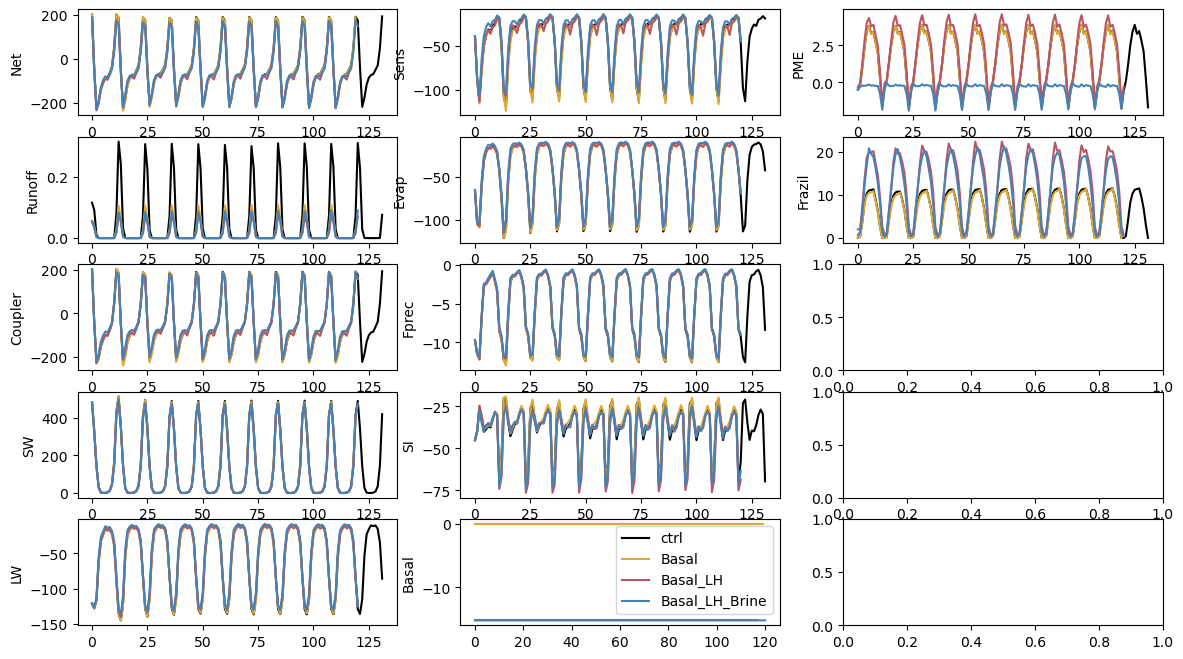

In [35]:
# ### calculate NET SHF:
HF_net_hint_shelf_ctrl = HF_runoff_hint_shelf_ctrl+HF_coupler_hint_shelf_ctrl+\
    HF_pme_hint_shelf_ctrl+HF_frazil_hint_shelf_ctrl

HF_net_hint_shelf_noBG = HF_runoff_hint_shelf_noBG+HF_coupler_hint_shelf_noBG+\
    HF_pme_hint_shelf_noBG+HF_frazil_hint_shelf_noBG+HF_basalmix_hint_shelf_noBG

HF_net_hint_shelf_BG = HF_runoff_hint_shelf_BG[0:118]+HF_coupler_hint_shelf_BG[0:118]+\
    HF_pme_hint_shelf_BG[0:118]+HF_frazil_hint_shelf_BG[0:118]+HF_basalmix_hint_shelf_BG[0:118]

HF_net_hint_shelf_BGB = HF_runoff_hint_shelf_BGB+HF_coupler_hint_shelf_BGB+\
    HF_pme_hint_shelf_BGB+HF_frazil_hint_shelf_BGB+HF_basalmix_hint_shelf_BGB

fig, ax  = plt.subplots(nrows=5,ncols=3, figsize = (14,8))

ax[0,0].plot(HF_net_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[0,0].plot(HF_net_hint_shelf_noBG*1e-12,label='Basal',color='#DDAA33')
ax[0,0].plot(HF_net_hint_shelf_BG*1e-12,label='Basal_LH', color='#BB5566')
ax[0,0].plot(HF_net_hint_shelf_BGB*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[0,0].set_ylabel('Net')

ax[1,0].plot(HF_runoff_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[1,0].plot(HF_runoff_hint_shelf_noBG*1e-12,label='Basal',color='#DDAA33')
ax[1,0].plot(HF_runoff_hint_shelf_BG*1e-12,label='Basal_LH', color='#BB5566')
ax[1,0].plot(HF_runoff_hint_shelf_BGB*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[1,0].set_ylabel('Runoff')

ax[2,0].plot(HF_coupler_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[2,0].plot(HF_coupler_hint_shelf_noBG*1e-12,label='Basal',color='#DDAA33')
ax[2,0].plot(HF_coupler_hint_shelf_BG*1e-12,label='Basal_LH', color='#BB5566')
ax[2,0].plot(HF_coupler_hint_shelf_BGB*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[2,0].set_ylabel('Coupler')

ax[3,0].plot(HF_sw_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[3,0].plot(HF_sw_hint_shelf_noBG*1e-12,label='Basal',color='#DDAA33')
ax[3,0].plot(HF_sw_hint_shelf_BG*1e-12,label='Basal_LH', color='#BB5566')
ax[3,0].plot(HF_sw_hint_shelf_BGB*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[3,0].set_ylabel('SW')

ax[4,0].plot(HF_lw_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[4,0].plot(HF_lw_hint_shelf_noBG*1e-12,label='Basal',color='#DDAA33')
ax[4,0].plot(HF_lw_hint_shelf_BG*1e-12,label='Basal_LH', color='#BB5566')
ax[4,0].plot(HF_lw_hint_shelf_BGB*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[4,0].set_ylabel('LW')

ax[0,1].plot(HF_sens_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[0,1].plot(HF_sens_hint_shelf_noBG*1e-12,label='Basal',color='#DDAA33')
ax[0,1].plot(HF_sens_hint_shelf_BG*1e-12,label='Basal_LH', color='#BB5566')
ax[0,1].plot(HF_sens_hint_shelf_BGB*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[0,1].set_ylabel('Sens')

ax[1,1].plot(HF_evap_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[1,1].plot(HF_evap_hint_shelf_noBG*1e-12,label='Basal',color='#DDAA33')
ax[1,1].plot(HF_evap_hint_shelf_BG*1e-12,label='Basal_LH', color='#BB5566')
ax[1,1].plot(HF_evap_hint_shelf_BGB*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[1,1].set_ylabel('Evap')

ax[2,1].plot(HF_fprec_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[2,1].plot(HF_fprec_hint_shelf_noBG*1e-12,label='Basal',color='#DDAA33')
ax[2,1].plot(HF_fprec_hint_shelf_BG*1e-12,label='Basal_LH', color='#BB5566')
ax[2,1].plot(HF_fprec_hint_shelf_BGB*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[2,1].set_ylabel('Fprec')

ax[3,1].plot(HF_mh_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[3,1].plot(HF_mh_hint_shelf_noBG*1e-12,label='Basal',color='#DDAA33')
ax[3,1].plot(HF_mh_hint_shelf_BG*1e-12,label='Basal_LH', color='#BB5566')
ax[3,1].plot(HF_mh_hint_shelf_BGB*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[3,1].set_ylabel('SI')

ax[4,1].plot(0*HF_basalmix_hint_shelf_BG*1e-12,label='ctrl',color='k')
ax[4,1].plot(HF_basalmix_hint_shelf_noBG*1e-12,label='Basal',color='#DDAA33')
ax[4,1].plot(HF_basalmix_hint_shelf_BG*1e-12,label='Basal_LH', color='#BB5566')
ax[4,1].plot(HF_basalmix_hint_shelf_BGB*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[4,1].set_ylabel('Basal')
ax[4,1].legend()

ax[0,2].plot(HF_pme_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[0,2].plot(HF_pme_hint_shelf_noBG*1e-12,label='Basal',color='#DDAA33')
ax[0,2].plot(HF_pme_hint_shelf_BG*1e-12,label='Basal_LH', color='#BB5566')
ax[0,2].plot(HF_pme_hint_shelf_BGB*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[0,2].set_ylabel('PME')

ax[1,2].plot(HF_frazil_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[1,2].plot(HF_frazil_hint_shelf_noBG*1e-12,label='Basal',color='#DDAA33')
ax[1,2].plot(HF_frazil_hint_shelf_BG*1e-12,label='Basal_LH', color='#BB5566')
ax[1,2].plot(HF_frazil_hint_shelf_BGB*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[1,2].set_ylabel('Frazil')






(-250.0, 250.0)

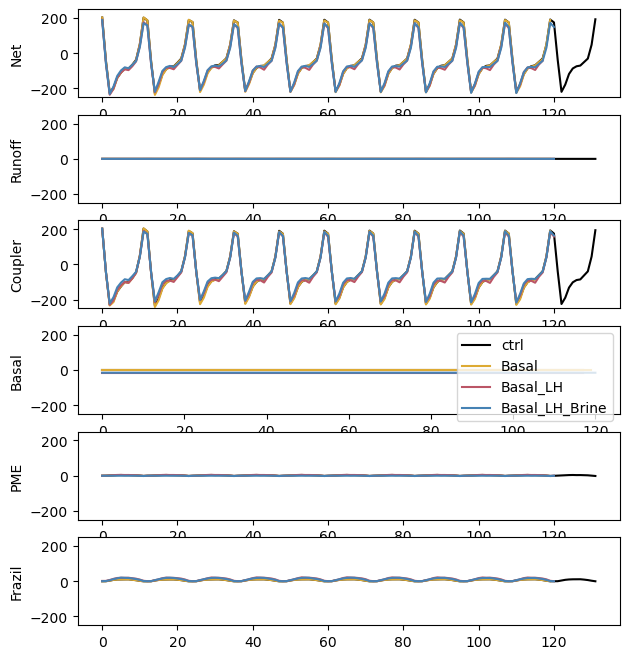

In [51]:
# Figure 1: Coupler condensed

fig, ax  = plt.subplots(nrows=6,ncols=1, figsize = (7,8))

ax[0].plot(HF_net_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[0].plot(HF_net_hint_shelf_noBG*1e-12,label='Basal',color='#DDAA33')
ax[0].plot(HF_net_hint_shelf_BG*1e-12,label='Basal_LH', color='#BB5566')
ax[0].plot(HF_net_hint_shelf_BGB*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[0].set_ylabel('Net')
ax[0].set_ylim(-250,250)

ax[1].plot(HF_runoff_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[1].plot(HF_runoff_hint_shelf_noBG*1e-12,label='Basal',color='#DDAA33')
ax[1].plot(HF_runoff_hint_shelf_BG*1e-12,label='Basal_LH', color='#BB5566')
ax[1].plot(HF_runoff_hint_shelf_BGB*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[1].set_ylabel('Runoff')
ax[1].set_ylim(-250,250)

ax[2].plot(HF_coupler_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[2].plot(HF_coupler_hint_shelf_noBG*1e-12,label='Basal',color='#DDAA33')
ax[2].plot(HF_coupler_hint_shelf_BG*1e-12,label='Basal_LH', color='#BB5566')
ax[2].plot(HF_coupler_hint_shelf_BGB*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[2].set_ylabel('Coupler')
ax[2].set_ylim(-250,250)

ax[3].plot(0*HF_basalmix_hint_shelf_BG*1e-12,label='ctrl',color='k')
ax[3].plot(HF_basalmix_hint_shelf_noBG*1e-12,label='Basal',color='#DDAA33')
ax[3].plot(HF_basalmix_hint_shelf_BG*1e-12,label='Basal_LH', color='#BB5566')
ax[3].plot(HF_basalmix_hint_shelf_BGB*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[3].set_ylabel('Basal')
ax[3].legend()
ax[3].set_ylim(-250,250)

ax[4].plot(HF_pme_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[4].plot(HF_pme_hint_shelf_noBG*1e-12,label='Basal',color='#DDAA33')
ax[4].plot(HF_pme_hint_shelf_BG*1e-12,label='Basal_LH', color='#BB5566')
ax[4].plot(HF_pme_hint_shelf_BGB*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[4].set_ylabel('PME')
ax[4].set_ylim(-250,250)

ax[5].plot(HF_frazil_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[5].plot(HF_frazil_hint_shelf_noBG*1e-12,label='Basal',color='#DDAA33')
ax[5].plot(HF_frazil_hint_shelf_BG*1e-12,label='Basal_LH', color='#BB5566')
ax[5].plot(HF_frazil_hint_shelf_BGB*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[5].set_ylabel('Frazil')
ax[5].set_ylim(-250,250)






(-250.0, 250.0)

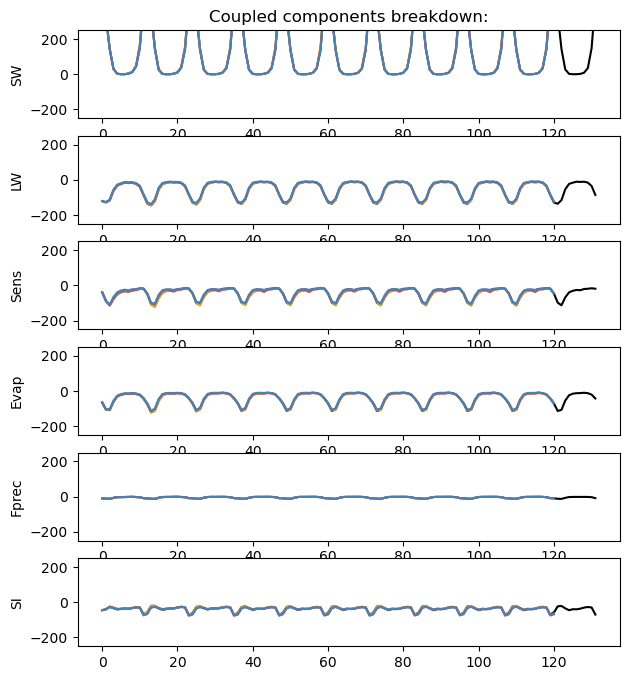

In [53]:

fig, ax  = plt.subplots(nrows=6,ncols=1, figsize = (7,8))

ax[0].set_title('Coupled components breakdown:')
ax[0].plot(HF_sw_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[0].plot(HF_sw_hint_shelf_noBG*1e-12,label='Basal',color='#DDAA33')
ax[0].plot(HF_sw_hint_shelf_BG*1e-12,label='Basal_LH', color='#BB5566')
ax[0].plot(HF_sw_hint_shelf_BGB*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[0].set_ylabel('SW')
ax[0].set_ylim(-250,250)

ax[1].plot(HF_lw_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[1].plot(HF_lw_hint_shelf_noBG*1e-12,label='Basal',color='#DDAA33')
ax[1].plot(HF_lw_hint_shelf_BG*1e-12,label='Basal_LH', color='#BB5566')
ax[1].plot(HF_lw_hint_shelf_BGB*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[1].set_ylabel('LW')
ax[1].set_ylim(-250,250)

ax[2].plot(HF_sens_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[2].plot(HF_sens_hint_shelf_noBG*1e-12,label='Basal',color='#DDAA33')
ax[2].plot(HF_sens_hint_shelf_BG*1e-12,label='Basal_LH', color='#BB5566')
ax[2].plot(HF_sens_hint_shelf_BGB*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[2].set_ylabel('Sens')
ax[2].set_ylim(-250,250)

ax[3].plot(HF_evap_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[3].plot(HF_evap_hint_shelf_noBG*1e-12,label='Basal',color='#DDAA33')
ax[3].plot(HF_evap_hint_shelf_BG*1e-12,label='Basal_LH', color='#BB5566')
ax[3].plot(HF_evap_hint_shelf_BGB*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[3].set_ylabel('Evap')
ax[3].set_ylim(-250,250)

ax[4].plot(HF_fprec_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[4].plot(HF_fprec_hint_shelf_noBG*1e-12,label='Basal',color='#DDAA33')
ax[4].plot(HF_fprec_hint_shelf_BG*1e-12,label='Basal_LH', color='#BB5566')
ax[4].plot(HF_fprec_hint_shelf_BGB*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[4].set_ylabel('Fprec')
ax[4].set_ylim(-250,250)

ax[5].plot(HF_mh_hint_shelf_ctrl*1e-12,label='ctrl',color='k')
ax[5].plot(HF_mh_hint_shelf_noBG*1e-12,label='Basal',color='#DDAA33')
ax[5].plot(HF_mh_hint_shelf_BG*1e-12,label='Basal_LH', color='#BB5566')
ax[5].plot(HF_mh_hint_shelf_BGB*1e-12,label='Basal_LH_Brine', color='steelblue')
ax[5].set_ylabel('SI')
ax[5].set_ylim(-250,250)



### old plots

In [ ]:
# plot with bars: last year annual avg, horizontally-integrated (over the shelf , depth<1000m only):
fig, ax  = plt.subplots(figsize = (10,6))

pyplot.bar(-.2, HF_runoff_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k', label='Control')
pyplot.bar(0, HF_runoff_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue', label='Basal')
pyplot.bar(0.2, HF_runoff_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange', label='ICB')

plt.legend()

pyplot.bar(.8, HF_coupler_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k', label='Control')
pyplot.bar(1, HF_coupler_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue', label='Basal')
pyplot.bar(1.2, HF_coupler_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange', label='ICB')

pyplot.bar(1.8, HF_sw_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(2, HF_sw_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(2.2, HF_sw_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')

pyplot.bar(2.8, HF_lw_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(3, HF_lw_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(3.2, HF_lw_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')

pyplot.bar(3.8, HF_sens_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(4, HF_sens_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(4.2, HF_sens_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')

pyplot.bar(4.8, HF_evap_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(5, HF_evap_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(5.2, HF_evap_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')

pyplot.bar(5.8, HF_fprec_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(6, HF_fprec_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(6.2, HF_fprec_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')

pyplot.bar(6.8, HF_mh_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(7, HF_mh_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(7.2, HF_mh_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')

pyplot.bar(8, HF_basalmix_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(8.2, HF_basalmix_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')

pyplot.bar(9, HF_icbmix_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(9.2, HF_icbmix_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')

pyplot.bar(9.8, HF_pme_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(10, HF_pme_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(10.2, HF_pme_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')

pyplot.bar(10.8, HF_frazil_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(11, HF_frazil_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(11.2, HF_frazil_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')

# calculate NET SHF:
HF_net_annual_hint_shelf_ctrl = HF_runoff_annual_hint_shelf_ctrl+HF_coupler_annual_hint_shelf_ctrl+\
    HF_pme_annual_hint_shelf_ctrl+HF_frazil_annual_hint_shelf_ctrl

HF_net_annual_hint_shelf_BG = HF_runoff_annual_hint_shelf_BG+HF_coupler_annual_hint_shelf_BG+\
    HF_pme_annual_hint_shelf_BG+HF_frazil_annual_hint_shelf_BG+HF_basalmix_annual_hint_shelf_BG+HF_icbmix_annual_hint_shelf_BG

HF_net_annual_hint_shelf_ICB = HF_runoff_annual_hint_shelf_ICB+HF_coupler_annual_hint_shelf_ICB+\
    HF_pme_annual_hint_shelf_ICB+HF_frazil_annual_hint_shelf_ICB+HF_basalmix_annual_hint_shelf_ICB+HF_icbmix_annual_hint_shelf_ICB

pyplot.bar(11.8, HF_net_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(12, HF_net_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(12.2, HF_net_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')

ax.set_xticks(np.arange(0,13),('Runoff','Coupler','SW','LW','Sens','Evap','Fprec','MH','Basal \n mix','ICB \n mix','PME','Frazil','Net'))
# ax.set_xticks(np.arange(1,6),('Runoff','Basal mix','ICB mix','PME','Frazil'))#,'MH'))
ax.set_xlabel('Surface flux components')
ax.set_ylabel('Heat flux (TW)')

plt.title('Shelf')

### Save fig
plt.savefig(figdir+'SHF_components_annual_hint_shelf_yr10.png')

In [ ]:
# plot with bars: last year annual avg, horizontally-integrated (over the shelf , depth<1000m only):
fig, ax  = plt.subplots(figsize = (10,6))

pyplot.bar(-.15, HF_runoff_annual_hint_shelf_ctrl*1e-12, width=0.15, color='k', label='Control')
pyplot.bar(0, HF_runoff_annual_hint_shelf_noBG*1e-12, width=0.15, color='#DDAA33', label='Basal')
pyplot.bar(0.15, HF_runoff_annual_hint_shelf_BG*1e-12, width=0.15, color='#BB5566', label='BasalGade')
pyplot.bar(0.3, HF_runoff_annual_hint_shelf_BGB*1e-12, width=0.15, color='steelblue', label='BasalGadeBrine')

plt.legend()

pyplot.bar(.85, HF_coupler_annual_hint_shelf_ctrl*1e-12, width=0.15, color='k', label='Control')
pyplot.bar(1, HF_coupler_annual_hint_shelf_noBG*1e-12, width=0.15, color='#DDAA33', label='Basal')
pyplot.bar(1.15, HF_coupler_annual_hint_shelf_BG*1e-12, width=0.15, color='#BB5566', label='BasalGade')
pyplot.bar(1.3, HF_coupler_annual_hint_shelf_BGB*1e-12, width=0.15, color='steelblue', label='BasalGadeBrine')

pyplot.bar(1.85, HF_sw_annual_hint_shelf_ctrl*1e-12, width=0.15, color='k')
pyplot.bar(2, HF_sw_annual_hint_shelf_noBG*1e-12, width=0.15, color='#DDAA33')
pyplot.bar(2.15, HF_sw_annual_hint_shelf_BG*1e-12, width=0.15, color='#BB5566')
pyplot.bar(2.3, HF_sw_annual_hint_shelf_BGB*1e-12, width=0.15, color='steelblue')

pyplot.bar(2.85, HF_lw_annual_hint_shelf_ctrl*1e-12, width=0.15, color='k')
pyplot.bar(3., HF_lw_annual_hint_shelf_noBG*1e-12, width=0.15, color='#DDAA33')
pyplot.bar(3.15, HF_lw_annual_hint_shelf_BG*1e-12, width=0.15, color='#BB5566')
pyplot.bar(3.3, HF_lw_annual_hint_shelf_BGB*1e-12, width=0.15, color='steelblue')

pyplot.bar(3.85, HF_sens_annual_hint_shelf_ctrl*1e-12, width=0.15, color='k')
pyplot.bar(4., HF_sens_annual_hint_shelf_noBG*1e-12, width=0.15, color='#DDAA33')
pyplot.bar(4.15, HF_sens_annual_hint_shelf_BG*1e-12, width=0.15, color='#BB5566')
pyplot.bar(4.3, HF_sens_annual_hint_shelf_BGB*1e-12, width=0.15, color='steelblue')

pyplot.bar(4.85, HF_evap_annual_hint_shelf_ctrl*1e-12, width=0.15, color='k')
pyplot.bar(5., HF_evap_annual_hint_shelf_noBG*1e-12, width=0.15, color='#DDAA33')
pyplot.bar(5.15, HF_evap_annual_hint_shelf_BG*1e-12, width=0.15, color='#BB5566')
pyplot.bar(5.3, HF_evap_annual_hint_shelf_BGB*1e-12, width=0.15, color='steelblue')

pyplot.bar(5.85, HF_fprec_annual_hint_shelf_ctrl*1e-12, width=0.15, color='k')
pyplot.bar(6., HF_fprec_annual_hint_shelf_noBG*1e-12, width=0.15, color='#DDAA33')
pyplot.bar(6.15, HF_fprec_annual_hint_shelf_BG*1e-12, width=0.15, color='#BB5566')
pyplot.bar(6.3, HF_fprec_annual_hint_shelf_BGB*1e-12, width=0.15, color='steelblue')

pyplot.bar(6.85, HF_mh_annual_hint_shelf_ctrl*1e-12, width=0.15, color='k')
pyplot.bar(7, HF_mh_annual_hint_shelf_noBG*1e-12, width=0.15, color='#DDAA33')
pyplot.bar(7.15, HF_mh_annual_hint_shelf_BG*1e-12, width=0.15, color='#BB5566')
pyplot.bar(7.3, HF_mh_annual_hint_shelf_BGB*1e-12, width=0.15, color='steelblue')

pyplot.bar(8, HF_basalmix_annual_hint_shelf_noBG*1e-12, width=0.15, color='#DDAA33')
pyplot.bar(8.15, HF_basalmix_annual_hint_shelf_BG*1e-12, width=0.15, color='#BB5566')
pyplot.bar(8.3, HF_basalmix_annual_hint_shelf_BGB*1e-12, width=0.15, color='steelblue')

# pyplot.bar(9, HF_icbmix_annual_hint_shelf_noBG*1e-12, width=0.15, color='#DDAA33')
# pyplot.bar(9.15, HF_icbmix_annual_hint_shelf_BG*1e-12, width=0.15, color='#BB5566')

pyplot.bar(9.85, HF_pme_annual_hint_shelf_ctrl*1e-12, width=0.15, color='k')
pyplot.bar(10, HF_pme_annual_hint_shelf_noBG*1e-12, width=0.15, color='#DDAA33')
pyplot.bar(10.15, HF_pme_annual_hint_shelf_BG*1e-12, width=0.15, color='#BB5566')
pyplot.bar(10.3, HF_pme_annual_hint_shelf_BGB*1e-12, width=0.15, color='steelblue')

pyplot.bar(10.85, HF_frazil_annual_hint_shelf_ctrl*1e-12, width=0.15, color='k')
pyplot.bar(11, HF_frazil_annual_hint_shelf_noBG*1e-12, width=0.15, color='#DDAA33')
pyplot.bar(11.15, HF_frazil_annual_hint_shelf_BG*1e-12, width=0.15, color='#BB5566')
pyplot.bar(11.3, HF_frazil_annual_hint_shelf_BGB*1e-12, width=0.15, color='steelblue')

### calculate NET SHF:
HF_net_annual_hint_shelf_ctrl = HF_runoff_annual_hint_shelf_ctrl+HF_coupler_annual_hint_shelf_ctrl+\
    HF_pme_annual_hint_shelf_ctrl+HF_frazil_annual_hint_shelf_ctrl

HF_net_annual_hint_shelf_noBG = HF_runoff_annual_hint_shelf_noBG+HF_coupler_annual_hint_shelf_noBG+\
    HF_pme_annual_hint_shelf_noBG+HF_frazil_annual_hint_shelf_noBG+HF_basalmix_annual_hint_shelf_noBG#+HF_icbmix_annual_hint_shelf_noBG

HF_net_annual_hint_shelf_BG = HF_runoff_annual_hint_shelf_BG+HF_coupler_annual_hint_shelf_BG+\
    HF_pme_annual_hint_shelf_BG+HF_frazil_annual_hint_shelf_BG+HF_basalmix_annual_hint_shelf_BG#+HF_icbmix_annual_hint_shelf_BG

HF_net_annual_hint_shelf_BGB = HF_runoff_annual_hint_shelf_BGB+HF_coupler_annual_hint_shelf_BGB+\
    HF_pme_annual_hint_shelf_BGB+HF_frazil_annual_hint_shelf_BGB+HF_basalmix_annual_hint_shelf_BGB

pyplot.bar(11.85, HF_net_annual_hint_shelf_ctrl*1e-12, width=0.15, color='k')
pyplot.bar(12, HF_net_annual_hint_shelf_noBG*1e-12, width=0.15, color='#DDAA33')
pyplot.bar(12.15, HF_net_annual_hint_shelf_BG*1e-12, width=0.15, color='#BB5566')
pyplot.bar(12.3, HF_net_annual_hint_shelf_BGB*1e-12, width=0.15, color='steelblue')

ax.set_xticks(np.arange(0,13),('Runoff','Coupler','SW','LW','Sens','Evap','Fprec','MH','Basal \n mix','ICB \n mix','PME','Frazil','Net'))
# ax.set_xticks(np.arange(1,6),('Runoff','Basal mix','ICB mix','PME','Frazil'))#,'MH'))
ax.set_xlabel('Surface flux components')
ax.set_ylabel('Heat flux (TW)')

plt.title('Shelf')

### Save fig
plt.savefig(figdir+'SHF_components_annual_hint_shelf_yr8-10.png')

In [ ]:
# print(HF_net_annual_hint_shelf_ctrl*1e-12, HF_net_annual_hint_shelf_noBG*1e-12, HF_net_annual_hint_shelf_BG*1e-12, HF_net_annual_hint_shelf_ICB*1e-12)

In [ ]:
print(' --- NET ---')
print('Control = ', HF_net_annual_hint_shelf_ctrl*1e-12)
print('BG = ', HF_net_annual_hint_shelf_BG*1e-12)
print('ICB = ', HF_net_annual_hint_shelf_ICB*1e-12)
print('noBG = ', HF_net_annual_hint_shelf_noBG*1e-12)
print('BGB = ', HF_net_annual_hint_shelf_BGB*1e-12)

print(' --- RUNOFF ---')
print('Control = ', HF_runoff_annual_hint_shelf_ctrl*1e-12)
print('BG = ', HF_runoff_annual_hint_shelf_BG*1e-12)
print('ICB = ', HF_runoff_annual_hint_shelf_ICB*1e-12)
print('noBG = ', HF_runoff_annual_hint_shelf_noBG*1e-12)
print('BGB = ', HF_runoff_annual_hint_shelf_BGB*1e-12)

print(' --- COUPLER ---')
print('Control = ', HF_coupler_annual_hint_shelf_ctrl*1e-12)
print('BG = ', HF_coupler_annual_hint_shelf_BG*1e-12)
print('ICB = ', HF_coupler_annual_hint_shelf_ICB*1e-12)
print('noBG = ', HF_coupler_annual_hint_shelf_noBG*1e-12)
print('BGB = ', HF_coupler_annual_hint_shelf_BGB*1e-12)

print(' --- SEA-ICE ---')
print('Control = ', HF_mh_annual_hint_shelf_ctrl*1e-12)
print('BG = ', HF_mh_annual_hint_shelf_BG*1e-12)
print('ICB = ', HF_mh_annual_hint_shelf_ICB*1e-12)
print('noBG = ', HF_mh_annual_hint_shelf_noBG*1e-12)
print('BGB = ', HF_mh_annual_hint_shelf_BGB*1e-12)

print(' --- BASAL/ICB MIX ---')
print('BG = ', (HF_basalmix_annual_hint_shelf_BG+HF_icbmix_annual_hint_shelf_BG)*1e-12)
print('ICB = ', (HF_basalmix_annual_hint_shelf_ICB+HF_icbmix_annual_hint_shelf_ICB)*1e-12)
print('noBG = ', (HF_basalmix_annual_hint_shelf_noBG)*1e-12)
print('BGB = ', (HF_basalmix_annual_hint_shelf_BGB)*1e-12)

print(' --- PME ---')
print('Control = ', HF_pme_annual_hint_shelf_ctrl*1e-12)
print('BG = ', HF_pme_annual_hint_shelf_BG*1e-12)
print('ICB = ', HF_pme_annual_hint_shelf_ICB*1e-12)
print('noBG = ', HF_pme_annual_hint_shelf_noBG*1e-12)
print('BGB = ', HF_pme_annual_hint_shelf_BGB*1e-12)

print(' --- FRAZIL ---')
print('Control = ', HF_frazil_annual_hint_shelf_ctrl*1e-12)
print('BG = ', HF_frazil_annual_hint_shelf_BG*1e-12)
print('ICB = ', HF_frazil_annual_hint_shelf_ICB*1e-12)
print('noBG = ', HF_frazil_annual_hint_shelf_noBG*1e-12)
print('BGB = ', HF_frazil_annual_hint_shelf_BGB*1e-12)


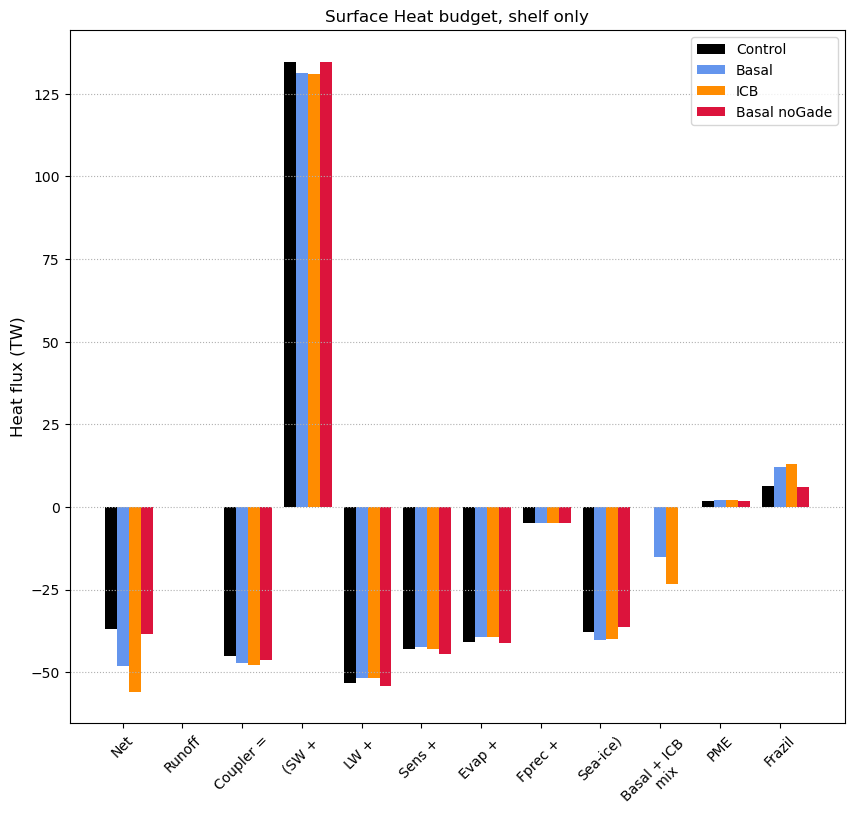

In [18]:
# plot with bars: last year annual avg, horizontally-integrated (over the shelf , depth<1000m only):
fig, ax  = plt.subplots(figsize = (10,9))

pyplot.bar(.8, HF_runoff_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k', label='Control')
pyplot.bar(1.0, HF_runoff_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue', label='Basal')
pyplot.bar(1.2, HF_runoff_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange', label='ICB')
pyplot.bar(1.4, HF_runoff_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson', label='Basal noGade')

plt.legend()

pyplot.bar(1.8, HF_coupler_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k', label='Control')
pyplot.bar(2, HF_coupler_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue', label='Basal')
pyplot.bar(2.2, HF_coupler_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange', label='ICB')
pyplot.bar(2.4, HF_coupler_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson', label='Basal noGade')

pyplot.bar(2.8, HF_sw_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(3, HF_sw_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(3.2, HF_sw_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')
pyplot.bar(3.4, HF_sw_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson')

pyplot.bar(3.8, HF_lw_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(4, HF_lw_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(4.2, HF_lw_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')
pyplot.bar(4.4, HF_lw_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson')

pyplot.bar(4.8, HF_sens_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(5, HF_sens_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(5.2, HF_sens_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')
pyplot.bar(5.4, HF_sens_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson')

pyplot.bar(5.8, HF_evap_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(6, HF_evap_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(6.2, HF_evap_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')
pyplot.bar(6.4, HF_evap_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson')

pyplot.bar(6.8, HF_fprec_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(7, HF_fprec_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(7.2, HF_fprec_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')
pyplot.bar(7.4, HF_fprec_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson')

pyplot.bar(7.8, HF_mh_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(8, HF_mh_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(8.2, HF_mh_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')
pyplot.bar(8.4, HF_mh_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson')

pyplot.bar(9, (HF_basalmix_annual_hint_shelf_BG)*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(9.2, (HF_basalmix_annual_hint_shelf_ICB+HF_icbmix_annual_hint_shelf_ICB)*1e-12, width=0.2, color='darkorange')
pyplot.bar(9.4, (HF_basalmix_annual_hint_shelf_noBG)*1e-12, width=0.2, color='crimson')

pyplot.bar(9.8, HF_pme_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(10.0, HF_pme_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(10.2, HF_pme_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')
pyplot.bar(10.4, HF_pme_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson')

pyplot.bar(10.8, HF_frazil_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(11, HF_frazil_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(11.2, HF_frazil_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')
pyplot.bar(11.4, HF_frazil_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson')

# calculate NET SHF:
HF_net_annual_hint_shelf_ctrl = HF_runoff_annual_hint_shelf_ctrl+HF_coupler_annual_hint_shelf_ctrl+\
            HF_pme_annual_hint_shelf_ctrl+HF_frazil_annual_hint_shelf_ctrl
HF_net_annual_hint_shelf_noBG = HF_runoff_annual_hint_shelf_noBG+HF_coupler_annual_hint_shelf_noBG+\
            HF_pme_annual_hint_shelf_noBG+HF_frazil_annual_hint_shelf_noBG+\
            HF_basalmix_annual_hint_shelf_noBG
HF_net_annual_hint_shelf_BG = HF_runoff_annual_hint_shelf_BG+HF_coupler_annual_hint_shelf_BG+\
            HF_pme_annual_hint_shelf_BG+HF_frazil_annual_hint_shelf_BG+\
            HF_basalmix_annual_hint_shelf_BG
HF_net_annual_hint_shelf_ICB = HF_runoff_annual_hint_shelf_ICB+HF_coupler_annual_hint_shelf_ICB+\
            HF_pme_annual_hint_shelf_ICB+HF_frazil_annual_hint_shelf_ICB+\
            HF_basalmix_annual_hint_shelf_ICB+HF_icbmix_annual_hint_shelf_ICB

pyplot.bar(-.2, HF_net_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(0, HF_net_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(.2, HF_net_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')
pyplot.bar(.4, HF_net_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson')

ax.set_xticks(np.arange(0,12),('Net','Runoff','Coupler =','(SW + ','LW + ','Sens + ','Evap + ','Fprec + ','Sea-ice)','Basal + ICB \n mix','PME','Frazil'), rotation=45) 
# ax.set_xlabel('Surface flux components')
ax.set_ylabel('Heat flux (TW)',fontsize=12)
plt.title('Surface Heat budget, shelf only')
ax.yaxis.grid(True, linestyle=':')

### Save fig
plt.savefig(figdir+'SHF_components_annual_hint_shelf_yr8-10_FinalFig.png')

NameError: name 'HF_icbmix_annual_hint_shelf_BG' is not defined

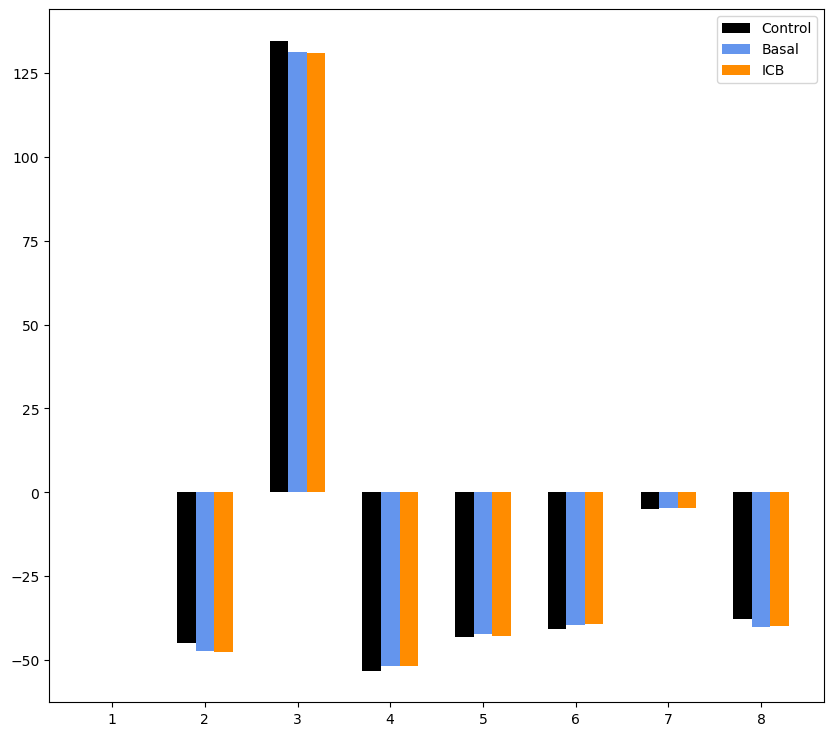

In [19]:
# plot with bars: last year annual avg, horizontally-integrated (over the shelf , depth<1000m only):
fig, ax  = plt.subplots(figsize = (10,9))

pyplot.bar(.8, HF_runoff_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k', label='Control')
pyplot.bar(1.0, HF_runoff_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue', label='Basal')
pyplot.bar(1.2, HF_runoff_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange', label='ICB')
# pyplot.bar(1.4, HF_runoff_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson', label='Basal noGade')

plt.legend()

pyplot.bar(1.8, HF_coupler_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k', label='Control')
pyplot.bar(2, HF_coupler_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue', label='Basal')
pyplot.bar(2.2, HF_coupler_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange', label='ICB')
# pyplot.bar(2.4, HF_coupler_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson', label='Basal noGade')

pyplot.bar(2.8, HF_sw_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(3, HF_sw_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(3.2, HF_sw_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')
# pyplot.bar(3.4, HF_sw_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson')

pyplot.bar(3.8, HF_lw_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(4, HF_lw_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(4.2, HF_lw_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')
# pyplot.bar(4.4, HF_lw_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson')

pyplot.bar(4.8, HF_sens_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(5, HF_sens_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(5.2, HF_sens_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')
# pyplot.bar(5.4, HF_sens_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson')

pyplot.bar(5.8, HF_evap_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(6, HF_evap_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(6.2, HF_evap_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')
# pyplot.bar(6.4, HF_evap_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson')

pyplot.bar(6.8, HF_fprec_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(7, HF_fprec_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(7.2, HF_fprec_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')
# pyplot.bar(7.4, HF_fprec_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson')

pyplot.bar(7.8, HF_mh_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(8, HF_mh_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(8.2, HF_mh_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')
# pyplot.bar(8.4, HF_mh_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson')

pyplot.bar(9, (HF_basalmix_annual_hint_shelf_BG+HF_icbmix_annual_hint_shelf_BG)*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(9.2, (HF_basalmix_annual_hint_shelf_ICB+HF_icbmix_annual_hint_shelf_ICB)*1e-12, width=0.2, color='darkorange')
# pyplot.bar(9.4, (HF_basalmix_annual_hint_shelf_noBG+HF_icbmix_annual_hint_shelf_noBG)*1e-12, width=0.2, color='crimson')

pyplot.bar(9.8, HF_pme_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(10.0, HF_pme_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(10.2, HF_pme_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')
# pyplot.bar(10.4, HF_pme_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson')

pyplot.bar(10.8, HF_frazil_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(11, HF_frazil_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(11.2, HF_frazil_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')
# pyplot.bar(11.4, HF_frazil_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson')

# calculate NET SHF:
HF_net_annual_hint_shelf_ctrl = HF_runoff_annual_hint_shelf_ctrl+HF_coupler_annual_hint_shelf_ctrl+\
            HF_pme_annual_hint_shelf_ctrl+HF_frazil_annual_hint_shelf_ctrl
HF_net_annual_hint_shelf_noBG = HF_runoff_annual_hint_shelf_noBG+HF_coupler_annual_hint_shelf_noBG+\
            HF_pme_annual_hint_shelf_noBG+HF_frazil_annual_hint_shelf_noBG+\
            HF_basalmix_annual_hint_shelf_noBG
HF_net_annual_hint_shelf_BG = HF_runoff_annual_hint_shelf_BG+HF_coupler_annual_hint_shelf_BG+\
            HF_pme_annual_hint_shelf_BG+HF_frazil_annual_hint_shelf_BG+\
            HF_basalmix_annual_hint_shelf_BG
HF_net_annual_hint_shelf_ICB = HF_runoff_annual_hint_shelf_ICB+HF_coupler_annual_hint_shelf_ICB+\
            HF_pme_annual_hint_shelf_ICB+HF_frazil_annual_hint_shelf_ICB+\
            HF_basalmix_annual_hint_shelf_ICB

pyplot.bar(-.2, HF_net_annual_hint_shelf_ctrl*1e-12, width=0.2, color='k')
pyplot.bar(0, HF_net_annual_hint_shelf_BG*1e-12, width=0.2, color='cornflowerblue')
pyplot.bar(.2, HF_net_annual_hint_shelf_ICB*1e-12, width=0.2, color='darkorange')
# pyplot.bar(.4, HF_net_annual_hint_shelf_noBG*1e-12, width=0.2, color='crimson')

ax.set_xticks(np.arange(0,12),('Net','Runoff','Coupler =','(SW + ','LW + ','Sens + ','Evap + ','Fprec + ','Sea-ice)','Basal + ICB \n mix','PME','Frazil'), rotation=45) 
# ax.set_xlabel('Surface flux components')
ax.set_ylabel('Heat flux (TW)',fontsize=12)
plt.title('Surface Heat budget, shelf only')
ax.yaxis.grid(True, linestyle=':')

### Save fig
plt.savefig(figdir+'SHF_components_annual_hint_shelf_yr10_FinalFig_WO_noBG.png')

In [ ]:
fig, ax  = plt.subplots(figsize = (10,6))
pyplot.bar(-.3, HF_runoff_annual_hint_shelf_ctrl*1e-12, width=0.25, color='k', label='Control')
pyplot.bar(0, HF_runoff_annual_hint_shelf_BG*1e-12, width=0.25, color='cornflowerblue', label='Basal')
pyplot.bar(0.3, HF_runoff_annual_hint_shelf_ICB*1e-12, width=0.25, color='darkorange', label='ICB')

# pyplot.bar(1., HF_basalmix_annual_hint_shelf_BG*1e-12, width=0.25, color='cornflowerblue')
# pyplot.bar(1.3, HF_basalmix_annual_hint_shelf_ICB*1e-12, width=0.25, color='darkorange')

# pyplot.bar(2, HF_icbmix_annual_hint_shelf_BG*1e-12, width=0.25, color='cornflowerblue')
# pyplot.bar(2.3, HF_icbmix_annual_hint_shelf_ICB*1e-12, width=0.25, color='darkorange')

ax.set_xticks(np.arange(0,2),('Runoff',''))
plt.legend()
ax.set_xlabel('Surface flux components')
ax.set_ylabel('Heat flux (TW)')

plt.title('Shelf')


In [ ]:
# plot with bars: last year annual avg, horizontal integrated (global):
fig, ax  = plt.subplots(figsize = (10,6))

pyplot.bar(-.3, HF_runoff_annual_hint_ctrl*1e-12, width=0.25, color='k', label='Control')
pyplot.bar(0, HF_runoff_annual_hint_BG*1e-12, width=0.25, color='cornflowerblue', label='Basal')
pyplot.bar(0.3, HF_runoff_annual_hint_ICB*1e-12, width=0.25, color='darkorange', label='ICB')

plt.legend()

pyplot.bar(.7, HF_coupler_annual_hint_ctrl*1e-12, width=0.25, color='k', label='Control')
pyplot.bar(1, HF_coupler_annual_hint_BG*1e-12, width=0.25, color='cornflowerblue', label='Basal')
pyplot.bar(1.3, HF_coupler_annual_hint_ICB*1e-12, width=0.25, color='darkorange', label='ICB')

pyplot.bar(1.7, HF_sw_annual_hint_ctrl*1e-12, width=0.25, color='k')
pyplot.bar(2, HF_sw_annual_hint_BG*1e-12, width=0.25, color='cornflowerblue')
pyplot.bar(2.3, HF_sw_annual_hint_ICB*1e-12, width=0.25, color='darkorange')

pyplot.bar(2.7, HF_lw_annual_hint_ctrl*1e-12, width=0.25, color='k')
pyplot.bar(3, HF_lw_annual_hint_BG*1e-12, width=0.25, color='cornflowerblue')
pyplot.bar(3.3, HF_lw_annual_hint_ICB*1e-12, width=0.25, color='darkorange')

pyplot.bar(3.7, HF_sens_annual_hint_ctrl*1e-12, width=0.25, color='k')
pyplot.bar(4, HF_sens_annual_hint_BG*1e-12, width=0.25, color='cornflowerblue')
pyplot.bar(4.3, HF_sens_annual_hint_ICB*1e-12, width=0.25, color='darkorange')

pyplot.bar(4.7, HF_evap_annual_hint_ctrl*1e-12, width=0.25, color='k')
pyplot.bar(5, HF_evap_annual_hint_BG*1e-12, width=0.25, color='cornflowerblue')
pyplot.bar(5.3, HF_evap_annual_hint_ICB*1e-12, width=0.25, color='darkorange')

pyplot.bar(5.7, HF_fprec_annual_hint_ctrl*1e-12, width=0.25, color='k')
pyplot.bar(6, HF_fprec_annual_hint_BG*1e-12, width=0.25, color='cornflowerblue')
pyplot.bar(6.3, HF_fprec_annual_hint_ICB*1e-12, width=0.25, color='darkorange')

pyplot.bar(6.7, HF_mh_annual_hint_ctrl*1e-12, width=0.25, color='k')
pyplot.bar(7, HF_mh_annual_hint_BG*1e-12, width=0.25, color='cornflowerblue')
pyplot.bar(7.3, HF_mh_annual_hint_ICB*1e-12, width=0.25, color='darkorange')

pyplot.bar(8, HF_basalmix_annual_hint_BG*1e-12, width=0.25, color='cornflowerblue')
pyplot.bar(8.3, HF_basalmix_annual_hint_ICB*1e-12, width=0.25, color='darkorange')

pyplot.bar(9, HF_icbmix_annual_hint_BG*1e-12, width=0.25, color='cornflowerblue')
pyplot.bar(9.3, HF_icbmix_annual_hint_ICB*1e-12, width=0.25, color='darkorange')

pyplot.bar(9.7, HF_pme_annual_hint_ctrl*1e-12, width=0.25, color='k')
pyplot.bar(10, HF_pme_annual_hint_BG*1e-12, width=0.25, color='cornflowerblue')
pyplot.bar(10.3, HF_pme_annual_hint_ICB*1e-12, width=0.25, color='darkorange')

pyplot.bar(10.7, HF_frazil_annual_hint_ctrl*1e-12, width=0.25, color='k')
pyplot.bar(11, HF_frazil_annual_hint_BG*1e-12, width=0.25, color='cornflowerblue')
pyplot.bar(11.3, HF_frazil_annual_hint_ICB*1e-12, width=0.25, color='darkorange')

# calculate NET SHF:
HF_net_annual_hint_ctrl = HF_runoff_annual_hint_ctrl+HF_coupler_annual_hint_ctrl+HF_pme_annual_hint_ctrl+HF_frazil_annual_hint_ctrl
HF_net_annual_hint_BG = HF_runoff_annual_hint_BG+HF_coupler_annual_hint_BG+HF_pme_annual_hint_BG+HF_frazil_annual_hint_BG+HF_basalmix_annual_hint_BG+HF_icbmix_annual_hint_BG
HF_net_annual_hint_ICB = HF_runoff_annual_hint_ICB+HF_coupler_annual_hint_ICB+HF_pme_annual_hint_ICB+HF_frazil_annual_hint_ICB+HF_basalmix_annual_hint_ICB+HF_icbmix_annual_hint_ICB

pyplot.bar(11.7, HF_net_annual_hint_ctrl*1e-12, width=0.25, color='k')
pyplot.bar(12, HF_net_annual_hint_BG*1e-12, width=0.25, color='cornflowerblue')
pyplot.bar(12.3, HF_net_annual_hint_ICB*1e-12, width=0.25, color='darkorange')

ax.set_xticks(np.arange(0,13),('Runoff','Coupler','SW','LW','Sens','Evap','Fprec','MH','Basal \n mix','ICB \n mix','PME','Frazil','Net'))
# ax.set_xticks(np.arange(1,6),('Runoff','Basal mix','ICB mix','PME','Frazil'))#,'MH'))
ax.set_xlabel('Surface flux components')
ax.set_ylabel('Heat flux (TW)')

plt.title('Global')

### Save fig
plt.savefig(figdir+'SHF_components_annual_hint_yr10.png')

In [ ]:
# fig2: maps annual-avg last year (yr10)

year = 10
scale_max = 1.2
rmin=0.
rmax=1e-7

fig  = plt.figure(1, figsize = (25,12))
norm = col.Normalize(vmin=-scale_max,vmax=scale_max)

# control
ax = fig.add_axes([0.0, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# plot:
cf = ax.pcolormesh(sfc_hflux_from_runoff.xt_ocean, sfc_hflux_from_runoff.yt_ocean, sfc_hflux_from_runoff.mean('time')*area_t, #norm = norm,
    cmap = cmocean.rain, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('Control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())


rmin=-1e-4
rmax=1e-4

# basal
ax = fig.add_axes([0.31, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# plot:
cfa = ax.pcolormesh(sfc_hflux_from_runoff_BG.xt_ocean, sfc_hflux_from_runoff_BG.yt_ocean, sfc_hflux_from_runoff_BG.mean('time')*area_t - sfc_hflux_from_runoff.mean('time')*area_t, #norm = norm,
    cmap = cm.bwr, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('Basal - control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# diff
ax = fig.add_axes([0.62, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
# verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
# plot:
cfa = ax.pcolormesh(sfc_hflux_from_runoff_ICB.xt_ocean, sfc_hflux_from_runoff_ICB.yt_ocean, sfc_hflux_from_runoff_ICB.mean('time')*area_t - sfc_hflux_from_runoff.mean('time')*area_t, #norm = norm,
    cmap = cm.bwr, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('ICB - control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# colorbar:
# cbaxes = fig.add_axes([0.93, 0.25, 0.012, 0.5]) #
cbaxes = fig.add_axes([0.015, 0.15, 0.25, 0.012]) #
cbar = plt.colorbar(cf, cax = cbaxes, orientation = 'horizontal',extend = 'max')
cbar.set_label(r'Surface heat flux due to river runoff',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

cbaxes = fig.add_axes([0.35, 0.15, 0.5, 0.012]) #
cbar = plt.colorbar(cfa, cax = cbaxes, orientation = 'horizontal',extend = 'both')
cbar.set_label(r'Surface heat flux anomalies due to river runoff',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

### Save fig
plt.savefig(figdir+'sfc_hflux_runoff_anom_y'+str(year)+'.png')

In [ ]:
# fig2: maps annual-avg last year (yr10)

year = 10
scale_max = 1.2
rmin=0.
rmax=1e7

fig  = plt.figure(1, figsize = (25,12))
norm = col.Normalize(vmin=-scale_max,vmax=scale_max)

# control
ax = fig.add_axes([0.0, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# plot:
cf = ax.pcolormesh(frazil_3d_int_z.xt_ocean, frazil_3d_int_z.yt_ocean, frazil_3d_int_z.mean('time')*area_t, #norm = norm,
    cmap = cmocean.ice, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('Control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# anomalies below:
rmin=-1e7
rmax=1e7

# basal
ax = fig.add_axes([0.31, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)

# plot:
cfa = ax.pcolormesh(frazil_3d_int_z_BG.xt_ocean, frazil_3d_int_z_BG.yt_ocean, frazil_3d_int_z_BG.mean('time')*area_t - frazil_3d_int_z.mean('time')*area_t, #norm = norm,
    cmap = cm.bwr, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('Basal - control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# diff
ax = fig.add_axes([0.62, 0.0, 0.3, 1],projection=ccrs.SouthPolarStereo())
theta = np.linspace(0, 2*np.pi, 100)
center, radius = [0.5, 0.5], 0.5
# verts = np.vstack([np.sin(theta), np.cos(theta)]).T
circle = mpath.Path(verts * radius + center)
ax.set_boundary(circle, transform=ax.transAxes)
# plot:
cfa = ax.pcolormesh(frazil_3d_int_z_ICB.xt_ocean, frazil_3d_int_z_ICB.yt_ocean, frazil_3d_int_z_ICB.mean('time')*area_t - frazil_3d_int_z.mean('time')*area_t, #norm = norm,
    cmap = cm.bwr, transform = ccrs.PlateCarree(), vmin=rmin, vmax=rmax)
# ax.contour(ht.xt_ocean,ht.yt_ocean,ht,levels=[1000,3000],colors='k',linewidths=0.5,transform = ccrs.PlateCarree())
plt.title('ICB - control',fontsize=fontsize)
ax.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='darkgrey',zorder=2,transform = ccrs.PlateCarree())
ax.set_extent([-180, 180, -90, -59.5], ccrs.PlateCarree())

# # colorbar:
# cbaxes = fig.add_axes([0.93, 0.25, 0.012, 0.5]) #
cbaxes = fig.add_axes([0.015, 0.15, 0.25, 0.012]) #
cbar = plt.colorbar(cf, cax = cbaxes, orientation = 'horizontal',extend = 'max')
cbar.set_label(r'Surface heat flux due to frazil formation',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

cbaxes = fig.add_axes([0.35, 0.15, 0.5, 0.012]) #
cbar = plt.colorbar(cfa, cax = cbaxes, orientation = 'horizontal',extend = 'both')
cbar.set_label(r'Surface heat flux anomalies due to frazil formation',fontsize=fontsize,labelpad=2)
cbar.ax.tick_params(labelsize=fontsize)

### Save fig
plt.savefig(figdir+'frazil_3d_int_z_anom_y'+str(year)+'.png')

In [ ]:
%%time

HF_runoff_hint_shelf_ctrl = np.empty(120)
HF_coupler_hint_shelf_ctrl = np.empty(120)
HF_pme_hint_shelf_ctrl = np.empty(120)
HF_frazil_hint_shelf_ctrl = np.empty(120)
HF_sw_hint_shelf_ctrl = np.empty(120)
HF_lw_hint_shelf_ctrl = np.empty(120)
HF_sens_hint_shelf_ctrl = np.empty(120)
HF_evap_hint_shelf_ctrl = np.empty(120)
HF_fprec_hint_shelf_ctrl = np.empty(120)
HF_basalmix_hint_shelf_ctrl = np.empty(120)
HF_icbmix_hint_shelf_ctrl = np.empty(120)
HF_mhflux_hint_shelf_ctrl = np.empty(120)

# horizontally-integrated:
for tt in np.arange(0,len(sfc_hflux_from_runoff[:,0,0])):
    HF_runoff_hint_shelf_ctrl[tt] = var_hint_shelf(sfc_hflux_from_runoff[tt,:,:])
    HF_coupler_hint_shelf_ctrl[tt] = var_hint_shelf(sfc_hflux_coupler[tt,:,:])
    HF_pme_hint_shelf_ctrl[tt] = var_hint_shelf(sfc_hflux_pme[tt,:,:])
    HF_frazil_hint_shelf_ctrl[tt] = var_hint_shelf(frazil_3d_int_z[tt,:,:])
    HF_sw_hint_shelf_ctrl[tt] = var_hint_shelf(swflx[tt,:,:])
    HF_lw_hint_shelf_ctrl[tt] = var_hint_shelf(lw_heat[tt,:,:])
    HF_sens_hint_shelf_ctrl[tt] = var_hint_shelf(sens_heat[tt,:,:])
    HF_evap_hint_shelf_ctrl[tt] = var_hint_shelf(evap_heat[tt,:,:])
    HF_fprec_hint_shelf_ctrl[tt] = var_hint_shelf(fprec_melt_heat[tt,:,:])
    HF_mhflux_hint_shelf_ctrl[tt] = var_hint_shelf(mhflux_ctrl[tt,:,:])

In [ ]:
HF_basalmix_annual_vint_BG.shape

In [ ]:
%%time

HF_runoff_hint_shelf_BG = np.empty(120)
HF_coupler_hint_shelf_BG = np.empty(120)
HF_pme_hint_shelf_BG = np.empty(120)
HF_frazil_hint_shelf_BG = np.empty(120)
HF_sw_hint_shelf_BG = np.empty(120)
HF_lw_hint_shelf_BG = np.empty(120)
HF_sens_hint_shelf_BG = np.empty(120)
HF_evap_hint_shelf_BG = np.empty(120)
HF_fprec_hint_shelf_BG = np.empty(120)
HF_basalmix_hint_shelf_BG = np.empty(120)
HF_icbmix_hint_shelf_BG = np.empty(120)
HF_mhflux_hint_shelf_BG = np.empty(120)

# horizontally-integrated:
for tt in np.arange(0,len(sfc_hflux_from_runoff[:,0,0])):
    HF_runoff_hint_shelf_BG[tt] = var_hint_shelf(sfc_hflux_from_runoff_BG[tt,:,:])
    HF_coupler_hint_shelf_BG[tt] = var_hint_shelf(sfc_hflux_coupler_BG[tt,:,:])
    HF_pme_hint_shelf_BG[tt] = var_hint_shelf(sfc_hflux_pme_BG[tt,:,:])
    HF_frazil_hint_shelf_BG[tt] = var_hint_shelf(frazil_3d_int_z_BG[tt,:,:])
    HF_sw_hint_shelf_BG[tt] = var_hint_shelf(swflx_BG[tt,:,:])
    HF_lw_hint_shelf_BG[tt] = var_hint_shelf(lw_heat_BG[tt,:,:])
    HF_sens_hint_shelf_BG[tt] = var_hint_shelf(sens_heat_BG[tt,:,:])
    HF_evap_hint_shelf_BG[tt] = var_hint_shelf(evap_heat_BG[tt,:,:])
    HF_fprec_hint_shelf_BG[tt] = var_hint_shelf(fprec_melt_heat_BG[tt,:,:])
    HF_mhflux_hint_shelf_BG[tt] = var_hint_shelf(mhflux_BG[tt,:,:])

for tt in np.arange(0,len(HF_basalmix_annual_vint_BG[:,0,0])):
    HF_basalmix_hint_shelf_BG[tt] = var_hint_shelf(HF_basalmix_annual_vint_BG[tt,:,:]) # vertical sum of basalmix:
    # HF_icbmix_hint_shelf_BG[tt] = var_hint_shelf(HF_icbmix_annual_vint_BG[tt,:,:]) # vertical sum of icbmix:

In [ ]:
%%time

HF_runoff_hint_shelf_ICB = np.empty(120)
HF_coupler_hint_shelf_ICB = np.empty(120)
HF_pme_hint_shelf_ICB = np.empty(120)
HF_frazil_hint_shelf_ICB = np.empty(120)
HF_sw_hint_shelf_ICB = np.empty(120)
HF_lw_hint_shelf_ICB = np.empty(120)
HF_sens_hint_shelf_ICB = np.empty(120)
HF_evap_hint_shelf_ICB = np.empty(120)
HF_fprec_hint_shelf_ICB = np.empty(120)
HF_basalmix_hint_shelf_ICB = np.empty(120)
HF_icbmix_hint_shelf_ICB = np.empty(120)
HF_mhflux_hint_shelf_ICB = np.empty(120)

# horizontally-integrated:
for tt in np.arange(0,len(sfc_hflux_from_runoff[:,0,0])):
    HF_runoff_hint_shelf_ICB[tt] = var_hint_shelf(sfc_hflux_from_runoff_ICB[tt,:,:])  
    HF_coupler_hint_shelf_ICB[tt] = var_hint_shelf(sfc_hflux_coupler_ICB[tt,:,:])
    HF_pme_hint_shelf_ICB[tt] = var_hint_shelf(sfc_hflux_pme_ICB[tt,:,:])
    HF_frazil_hint_shelf_ICB[tt] = var_hint_shelf(frazil_3d_int_z_ICB[tt,:,:])
    HF_sw_hint_shelf_ICB[tt] = var_hint_shelf(swflx_ICB[tt,:,:])
    HF_lw_hint_shelf_ICB[tt] = var_hint_shelf(lw_heat_ICB[tt,:,:])
    HF_sens_hint_shelf_ICB[tt] = var_hint_shelf(sens_heat_ICB[tt,:,:])
    HF_evap_hint_shelf_ICB[tt] = var_hint_shelf(evap_heat_ICB[tt,:,:])
    HF_fprec_hint_shelf_ICB[tt] = var_hint_shelf(fprec_melt_heat_ICB[tt,:,:])
    HF_mhflux_hint_shelf_ICB[tt] = var_hint_shelf(mhflux_ICB[tt,:,:])

for tt in np.arange(0,len(HF_basalmix_annual_vint_ICB[:,0,0])):
    HF_basalmix_hint_shelf_ICB[tt] = var_hint_shelf(HF_basalmix_annual_vint_ICB[tt,:,:]) # vertical sum of basalmix:
    HF_icbmix_hint_shelf_ICB[tt] = var_hint_shelf(HF_icbmix_annual_vint_ICB[tt,:,:]) # vertical sum of icbmix:

In [ ]:
# fig 1: timeseries sfc_hflux_from_runoff area-weighted, averaged horizontally: all years
time = np.arange(0,120)
time_yr = np.divide(time,12)

fig, ax = plt.subplots(nrows=5, figsize = (12, 15))
ax[0].plot(time_yr,HF_runoff_hint_shelf_ctrl, label='Control') # not divided by total area
ax[0].plot(time_yr,HF_runoff_hint_shelf_BG, label='Basal')
ax[0].plot(time_yr,HF_runoff_hint_shelf_ICB, label='ICB')
ax[0].legend()
# ax[0].set_xlabel('Years')
ax[0].set_ylabel('Area-weighted surface heat fluxes (W)')
ax[0].title.set_text('Runoff')

ax[1].plot(time_yr,HF_coupler_hint_shelf_ctrl, label='Control') # not divided by total area
ax[1].plot(time_yr,HF_coupler_hint_shelf_BG, label='Basal')
ax[1].plot(time_yr,HF_coupler_hint_shelf_ICB, label='ICB')
ax[1].legend()
# ax[1].set_xlabel('Years')
ax[1].set_ylabel('Area-weighted surface heat fluxes (W)')
ax[1].title.set_text('Coupler')

# Ctrl
ax[2].plot(time_yr,HF_sw_hint_shelf_ctrl, '-r', label='SW - Control') # not divided by total area
ax[2].plot(time_yr,HF_lw_hint_shelf_ctrl, '-g',label='LW - Control') # not divided by total area
ax[2].plot(time_yr,HF_evap_hint_shelf_ctrl, '-b',label='Latent Heat - Control') # not divided by total area
ax[2].plot(time_yr,HF_sens_hint_shelf_ctrl, '-y',label='Sensible Heat - Control') # not divided by total area
ax[2].plot(time_yr,HF_fprec_hint_shelf_ctrl, '-c',label='F. precip. - Control') # not divided by total area
# BG
ax[2].plot(time_yr,HF_sw_hint_shelf_BG, '--r', label='SW - Basal') # not divided by total area
ax[2].plot(time_yr,HF_lw_hint_shelf_BG, '--g',label='LW - Basal') # not divided by total area
ax[2].plot(time_yr,HF_evap_hint_shelf_BG, '--b',label='Latent Heat - Basal') # not divided by total area
ax[2].plot(time_yr,HF_sens_hint_shelf_BG, '--y',label='Sensible Heat - Basal') # not divided by total area
ax[2].plot(time_yr,HF_fprec_hint_shelf_BG, '--c',label='F. precip. - Basal') # not divided by total area
# ICB
ax[2].plot(time_yr,HF_sw_hint_shelf_ICB, ':r', label='SW - ICB') # not divided by total area
ax[2].plot(time_yr,HF_lw_hint_shelf_ICB, ':g',label='LW - ICB') # not divided by total area
ax[2].plot(time_yr,HF_evap_hint_shelf_ICB, ':b',label='Latent Heat - ICB') # not divided by total area
ax[2].plot(time_yr,HF_sens_hint_shelf_ICB, ':y',label='Sensible Heat - ICB') # not divided by total area
ax[2].plot(time_yr,HF_fprec_hint_shelf_ICB, ':c',label='F. precip. - ICB') # not divided by total area
ax[2].set_ylabel('Area-weighted surface heat fluxes (W)')
ax[2].title.set_text('Couler components')

# calculate NET SHF:
HF_net_hint_shelf_ctrl = HF_runoff_hint_shelf_ctrl+HF_coupler_hint_shelf_ctrl+HF_pme_hint_shelf_ctrl+HF_frazil_hint_shelf_ctrl
HF_net_hint_shelf_BG = HF_runoff_hint_shelf_BG+HF_coupler_hint_shelf_BG+HF_pme_hint_shelf_BG+HF_frazil_hint_shelf_BG+HF_basalmix_hint_shelf_BG+HF_icbmix_hint_shelf_BG
HF_net_hint_shelf_ICB = HF_runoff_hint_shelf_ICB+HF_coupler_hint_shelf_ICB+HF_pme_hint_shelf_ICB+HF_frazil_hint_shelf_ICB+HF_basalmix_hint_shelf_ICB+HF_icbmix_hint_shelf_ICB

ax[3].plot(time_yr,HF_net_hint_shelf_ctrl, label='Control') # not divided by total area
ax[3].plot(time_yr,HF_net_hint_shelf_BG, label='Basal')
ax[3].plot(time_yr,HF_net_hint_shelf_ICB, label='ICB')
ax[3].legend()
# ax[3].set_xlabel('Years')
ax[3].set_ylabel('Area-weighted surface heat fluxes (W)')
ax[3].title.set_text('Net SHF')

ax[4].plot(time_yr,HF_frazil_hint_shelf_ctrl, label='Control') # not divided by total area
ax[4].plot(time_yr,HF_net_hint_shelf_BG, label='Basal')
ax[4].plot(time_yr,HF_net_hint_shelf_ICB, label='ICB')
ax[4].legend()
ax[4].set_xlabel('Years')
ax[4].set_ylabel('Area-weighted surface heat fluxes (W)')
ax[4].title.set_text('Frazil and PME')

### Save fig
plt.savefig(figdir+'Timeseries_SHF_components.png')


In [ ]:

# fig 1: timeseries sfc_hflux_from_runoff area-weighted, averaged horizontally:
time = np.arange(0,120)
time_yr = np.divide(time,12)
plt.plot(time_yr,HF_runoff_hint_shelf_ctrl, label='Runoff') # not divided by total area
# plt.plot(time_yr,HF_coupler_hint_shelf_ctrl, label='Coupler') # not divided by total area
plt.plot(time_yr,HF_pme_hint_shelf_ctrl, label='PME') # not divided by total area
plt.plot(time_yr,HF_frazil_hint_shelf_ctrl, label='Frazil') # not divided by total area
# plt.plot(time_yr,HF_sw_hint_shelf_ctrl, label='Shortwave') # not divided by total area
# plt.plot(time_yr,HF_lw_hint_shelf_ctrl, label='Longwave') # not divided by total area
# plt.plot(time_yr,HF_sens_hint_shelf_ctrl, label='Sensible heat') # not divided by total area
# plt.plot(time_yr,HF_evap_hint_shelf_ctrl, label='Latent heat') # not divided by total area
# plt.plot(time_yr,HF_fprec_hint_shelf_ctrl, label='Melt of frozen prec.') # not divided by total area

plt.legend(bbox_to_anchor=(1.04, 1), borderaxespad=0)
plt.xlabel('Years')
plt.ylabel('Area-weighted surface heat flux \n due to river runoff (W)')

Text(0, 0.5, 'Area-weighted surface heat flux \n due to river runoff (W)')

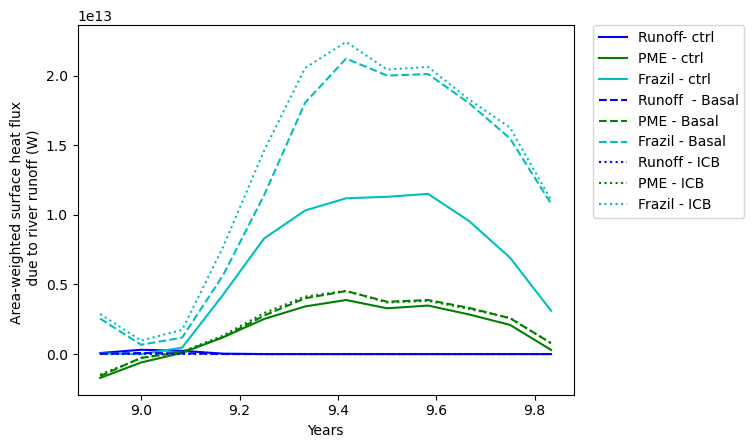

In [27]:
# fig 1: timeseries sfc_hflux_from_runoff area-weighted, averaged horizontally:
time = np.arange(0,120)
time_yr = np.divide(time,12)
plt.plot(time_yr[107:-1],HF_runoff_hint_shelf_ctrl[107:-1], label='Runoff- ctrl',color='b', linestyle='-') # not divided by total area
plt.plot(time_yr[107:-1],HF_pme_hint_shelf_ctrl[107:-1], label='PME - ctrl',color='g', linestyle='-') # not divided by total area
plt.plot(time_yr[107:-1],HF_frazil_hint_shelf_ctrl[107:-1], label='Frazil - ctrl',color='c', linestyle='-') # not divided by total area
plt.plot(time_yr[107:-1],HF_runoff_hint_shelf_BG[107:-1], label='Runoff  - Basal',color='b', linestyle='--') # not divided by total area
plt.plot(time_yr[107:-1],HF_pme_hint_shelf_BG[107:-1], label='PME - Basal',color='g', linestyle='--') # not divided by total area
plt.plot(time_yr[107:-1],HF_frazil_hint_shelf_BG[107:-1], label='Frazil - Basal',color='c', linestyle='--') # not divided by total area
plt.plot(time_yr[107:-1],HF_runoff_hint_shelf_ICB[107:-1], label='Runoff - ICB',color='b', linestyle=':') # not divided by total area
plt.plot(time_yr[107:-1],HF_pme_hint_shelf_ICB[107:-1], label='PME - ICB',color='g', linestyle=':') # not divided by total area
plt.plot(time_yr[107:-1],HF_frazil_hint_shelf_ICB[107:-1], label='Frazil - ICB',color='c', linestyle=':') # not divided by total area


plt.legend(bbox_to_anchor=(1.04, 1), borderaxespad=0)
plt.xlabel('Years')
plt.ylabel('Area-weighted surface heat flux \n due to river runoff (W)')

Text(0, 0.5, 'Area-weighted surface heat flux \n due to river runoff (W)')

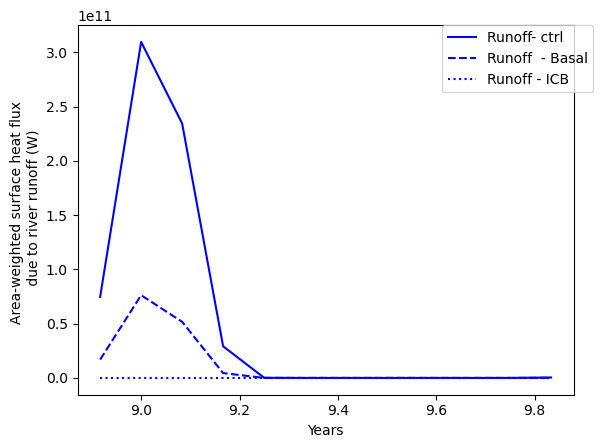

In [28]:
# fig 1: timeseries sfc_hflux_from_runoff area-weighted, averaged horizontally:
time = np.arange(0,120)
time_yr = np.divide(time,12)
plt.plot(time_yr[107:-1],HF_runoff_hint_shelf_ctrl[107:-1], label='Runoff- ctrl',color='b', linestyle='-') # not divided by total area
plt.plot(time_yr[107:-1],HF_runoff_hint_shelf_BG[107:-1], label='Runoff  - Basal',color='b', linestyle='--') # not divided by total area
plt.plot(time_yr[107:-1],HF_runoff_hint_shelf_ICB[107:-1], label='Runoff - ICB',color='b', linestyle=':') # not divided by total area

plt.legend(bbox_to_anchor=(1.04, 1), borderaxespad=0)
plt.xlabel('Years')
plt.ylabel('Area-weighted surface heat flux \n due to river runoff (W)')

In [29]:
time_yr[107:-1].shape

(12,)